<a href="https://colab.research.google.com/github/SuyogPatgave/Python_Codes-Projects/blob/main/CRM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import and View


Importing library packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

Data Import

In [2]:
acc= pd.read_csv('/content/accounts.csv')
data_dic = pd.read_csv('/content/data_dictionary.csv')
prdts = pd.read_csv('/content/products.csv')
sales_pipe = pd.read_csv('/content/sales_pipeline.csv')
sales_team = pd.read_csv('/content/sales_teams.csv')

In [3]:
pd.set_option('display.width', 300)
pd.set_option('display.max_columns', None)

Consolidating all datasets (assigning names for referential convenience) in one list

In [4]:
datasets = [('accounts', acc), ('data dictionary', data_dic), ('products', prdts), ('sales pipeline', sales_pipe), ('sales team', sales_team)]

Data Visibility

In [5]:
for name, dataset in datasets:
  print(f"\n\n\n{name.title()}:")
  print(dataset.head(10))
  print(f"--Dimensions: {dataset.shape}")




Accounts:
            account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation      technolgy              1996  1100.04       2822   United States               NaN
1        Betasoloin        medical              1999   251.41        495   United States               NaN
2          Betatech        medical              1986   647.18       1185           Kenya               NaN
3        Bioholding        medical              2012   587.34       1356      Philipines               NaN
4           Bioplex        medical              1991   326.82       1016   United States               NaN
5          Blackzim         retail              2009   497.11       1588   United States               NaN
6     Bluth Company      technolgy              1993  1242.32       3027   United States  Acme Corporation
7        Bubba Gump       software              2002   987.39       2253   United States               NaN
8           Cancity     

Data Description

In [6]:
  for name, dataset in datasets:
    print(f"\n\n\n{name.title()}:")
    print(dataset.describe())




Accounts:
       year_established       revenue     employees
count         85.000000     85.000000     85.000000
mean        1996.105882   1994.632941   4660.823529
std            8.865427   2169.491436   5715.601198
min         1979.000000      4.540000      9.000000
25%         1989.000000    497.110000   1179.000000
50%         1996.000000   1223.720000   2769.000000
75%         2002.000000   2741.370000   5595.000000
max         2017.000000  11698.030000  34288.000000



Data Dictionary:
                 Table    Field   Description
count               21       21            21
unique               4       18            19
top     sales_pipeline  account  Company name
freq                 8        2             2



Products:
        sales_price
count      7.000000
mean    6023.571429
std     9388.428070
min       55.000000
25%      823.000000
50%     3393.000000
75%     5151.500000
max    26768.000000



Sales Pipeline:
        close_value
count   6711.000000
mean    1490.9155

# Data Pre-Processing

######At this stage of the project, I'm just cleaning the information! It begins with inspection of any given dataset and then taking relevant actions to counter the redundant information or formatting the available information to uniformally process the data in the further analytical pipeline.

Account Table

In [7]:
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,NaN
81,Zencorporation,technolgy,2011,40.79,142,China,NaN
82,Zoomit,entertainment,1992,324.19,978,United States,NaN
83,Zotware,software,1979,4478.47,13809,United States,NaN


In [8]:
# Focusing on "Categorical variables", grouping them together to make a list
acc_cols = acc[['account', 'sector', 'office_location', 'subsidiary_of']]

In [9]:
# Creating a function to provide us with: Name of the column from the table/dataframe
# Frequency of each categorical value
# Total number of null values
# Dimension of the dataset
# The data type of each column
def short_summary(df):
  for columns in df:
      print(f"\n\n\nColumn Name: {df[columns].name}")
      print(df[columns].value_counts())
      print(f"Number of Null values: {df[columns].isnull().sum()}")
      print(f"Dimensions--{df.shape}")
      print(f"Data type: {df[columns].dtype}")

In [10]:
'''for columns in acc_cols:
  print(f"\n\n\nColumn Name: {acc_cols[columns].name}")
  print(f"Number of Null values: {acc_cols[columns].isnull().sum()}")
  print(acc_cols[columns].value_counts())'''
short_summary(acc_cols)
# Why are we doing this?!
# It helps us understand if there're any error in the categorical values, such as spelling/wording error.
# Also it helps us understand the frequency of each nique value occuring in the dataset
# Example: Is there a "retail" sector and a "Retail" sector




Column Name: account
account
Acme Corporation    1
Betasoloin          1
Betatech            1
Bioholding          1
Bioplex             1
                   ..
Zathunicon          1
Zencorporation      1
Zoomit              1
Zotware             1
Zumgoity            1
Name: count, Length: 85, dtype: int64
Number of Null values: 0
Dimensions--(85, 4)
Data type: object



Column Name: sector
sector
retail                17
technolgy             12
medical               12
marketing              8
finance                8
software               7
entertainment          6
telecommunications     6
services               5
employment             4
Name: count, dtype: int64
Number of Null values: 0
Dimensions--(85, 4)
Data type: object



Column Name: office_location
office_location
United States    71
Kenya             1
Philipines        1
Japan             1
Italy             1
Norway            1
Korea             1
Jordan            1
Brazil            1
Germany           1
Panama  

In [11]:
# Since not all the accounts are subsidiary of any parent company, we'll be assigning
# a label value "Not a subsidiary" to all the null values in the column "subsidiary of"
# This may later help in EDA/classification of the data!
acc.subsidiary_of =  acc.subsidiary_of.fillna('Not a Subsidiary')
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


In [12]:
acc['sector']= acc['sector'].astype('category')

In [13]:
#Viewing Table
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


Products Table

In [14]:
prdts
#Seems pretty simple and straightforward table, more like a reference table to
# simple information on the products. Moving on....!

,product,series,sales_price
0,GTX Basic,GTX,550
1,GTX Pro,GTX,4821
2,MG Special,MG,55
3,MG Advanced,MG,3393
4,GTX Plus Pro,GTX,5482
5,GTX Plus Basic,GTX,1096
6,GTK 500,GTK,26768


Sales Pipeline Table

In [15]:
# This table is of high significance. I call this as an action table which pretty much closely aligns with the fact table in start/snowflake configuration.
sales_pipe

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN


In [16]:
sales_pipe_cols = sales_pipe[['sales_agent', 'product', 'account', 'deal_stage']]

In [17]:
'''for values in sales_pipe_cols:
  print(f"\n\n\n{values}")
  print(f"Number of Null values: {sales_pipe_cols[values].isnull().sum()}")
  print(sales_pipe_cols[values].value_counts())'''

short_summary(sales_pipe_cols)




Column Name: sales_agent
sales_agent
Darcel Schlecht       747
Vicki Laflamme        451
Anna Snelling         448
Kary Hendrixson       438
Kami Bicknell         362
Versie Hillebrand     361
Zane Levy             349
Cassey Cress          346
Jonathan Berthelot    345
Gladys Colclough      317
Lajuana Vencill       311
Corliss Cosme         310
Markita Hansen        306
Maureen Marcano       285
Marty Freudenburg     281
Donn Cantrell         275
James Ascencio        267
Violet Mclelland      261
Moses Frase           260
Daniell Hammack       259
Niesha Huffines       239
Reed Clapper          237
Boris Faz             210
Cecily Lampkin        203
Hayden Neloms         202
Elease Gluck          177
Rosalina Dieter       160
Rosie Papadopoulos    160
Garret Kinder         123
Wilburn Farren        110
Name: count, dtype: int64
Number of Null values: 0
Dimensions--(8800, 4)
Data type: object



Column Name: product
product
GTX Basic         1866
MG Special        1651
GTXPro     

In [18]:
#Converting date values to date data type, converting from string/object

sales_pipe['close_date'] = pd.to_datetime(sales_pipe['close_date'])
sales_pipe['engage_date'] = pd.to_datetime(sales_pipe['engage_date'])


#Converting Deal stage to factor/category

sales_pipe['deal_satge'] = sales_pipe['deal_stage'].astype('category')

In [19]:
sales_pipe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   opportunity_id  8800 non-null   object        
 1   sales_agent     8800 non-null   object        
 2   product         8800 non-null   object        
 3   account         7375 non-null   object        
 4   deal_stage      8800 non-null   object        
 5   engage_date     8300 non-null   datetime64[ns]
 6   close_date      6711 non-null   datetime64[ns]
 7   close_value     6711 non-null   float64       
 8   deal_satge      8800 non-null   category      
dtypes: category(1), datetime64[ns](2), float64(1), object(5)
memory usage: 558.9+ KB


In [20]:
# for view
sales_pipe

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won
...,...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting


Null/NaN values in Sales Pipe

In [21]:
# Inspecting records where account is null/NaN in the dataset
# This will give us an idea about the null values and what the data effectively stands for/conveys the information

sales_pipe_null_acc =  sales_pipe[sales_pipe['account'].isnull()]
print(sales_pipe_null_acc)
print(f"Records by deal stages:- \n {sales_pipe_null_acc['deal_stage'].value_counts()}") # This will provide us with the unique values in the column "Deal_Stage" and their frequency
print(sales_pipe_null_acc.shape) #total number of records for null accounts dataset

# deduction:
# null values in account column represent two distinctiv deal stages: Engaging
# and prospecting


     opportunity_id        sales_agent         product account   deal_stage engage_date close_date  close_value   deal_satge
9          HAXMC4IX     James Ascencio     MG Advanced     NaN     Engaging  2016-11-03        NaT          NaN     Engaging
42         EG7OFLFR      Kami Bicknell       GTX Basic     NaN     Engaging  2016-11-14        NaT          NaN     Engaging
44         OLVI7L8M       Cassey Cress          GTXPro     NaN     Engaging  2016-11-16        NaT          NaN     Engaging
56         F5U1ACDD      Kami Bicknell  GTX Plus Basic     NaN     Engaging  2016-11-19        NaT          NaN     Engaging
60         ZZY4516R      Hayden Neloms     MG Advanced     NaN     Engaging  2016-11-20        NaT          NaN     Engaging
...             ...                ...             ...     ...          ...         ...        ...          ...          ...
8795       9MIWFW5J  Versie Hillebrand     MG Advanced     NaN  Prospecting         NaT        NaT          NaN  Prospecting


Dividing sales pipe table in 'Won + Lost', 'Engaging', and 'Prospecting'

In [22]:
# Data Subset for "WON" and "LOST"

sales_pipe_labelled = sales_pipe[(sales_pipe['deal_stage'] == 'Won') | (sales_pipe['deal_stage'] == 'Lost')]
print(sales_pipe_labelled)

#print(sales_pipe_labelled['deal_stage'].value_counts())

short_summary(sales_pipe_labelled)

# You may notice that the entire data subset (WON + LOST) has no null values.

     opportunity_id       sales_agent         product        account deal_stage engage_date close_date  close_value deal_satge
0          1C1I7A6R       Moses Frase  GTX Plus Basic        Cancity        Won  2016-10-20 2017-03-01       1054.0        Won
1          Z063OYW0   Darcel Schlecht          GTXPro          Isdom        Won  2016-10-25 2017-03-11       4514.0        Won
2          EC4QE1BX   Darcel Schlecht      MG Special        Cancity        Won  2016-10-25 2017-03-07         50.0        Won
3          MV1LWRNH       Moses Frase       GTX Basic        Codehow        Won  2016-10-25 2017-03-09        588.0        Won
4          PE84CX4O         Zane Levy       GTX Basic         Hatfan        Won  2016-10-25 2017-03-02        517.0        Won
...             ...               ...             ...            ...        ...         ...        ...          ...        ...
8295       2EBLR9N8   Lajuana Vencill       GTX Basic        Conecom        Won  2017-12-24 2017-12-26        6

In [23]:
#Viewing Labelled Data
sales_pipe_labelled

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won
...,...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,Won
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,Won
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,Won
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,Won


In [24]:
# Data Subset for Engaging

sales_pipe_engage = sales_pipe[(sales_pipe["deal_stage"])=="Engaging"]
print(sales_pipe_engage)

short_summary(sales_pipe_engage)
print(f"Total engaging records with an account: {sum(sales_pipe_engage['account'].value_counts())}")

     opportunity_id      sales_agent         product    account deal_stage engage_date close_date  close_value deal_satge
9          HAXMC4IX   James Ascencio     MG Advanced        NaN   Engaging  2016-11-03        NaT          NaN   Engaging
25         UP409DSB  Maureen Marcano     MG Advanced  Ganjaflex   Engaging  2016-11-10        NaT          NaN   Engaging
42         EG7OFLFR    Kami Bicknell       GTX Basic        NaN   Engaging  2016-11-14        NaT          NaN   Engaging
44         OLVI7L8M     Cassey Cress          GTXPro        NaN   Engaging  2016-11-16        NaT          NaN   Engaging
56         F5U1ACDD    Kami Bicknell  GTX Plus Basic        NaN   Engaging  2016-11-19        NaT          NaN   Engaging
...             ...              ...             ...        ...        ...         ...        ...          ...        ...
8277       NGTVHTFH        Boris Faz          GTXPro        NaN   Engaging  2017-12-19        NaT          NaN   Engaging
8283       HB740BLB    H

In [25]:
#Viewing data
sales_pipe_engage

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaT,NaN,Engaging
25,UP409DSB,Maureen Marcano,MG Advanced,Ganjaflex,Engaging,2016-11-10,NaT,NaN,Engaging
42,EG7OFLFR,Kami Bicknell,GTX Basic,NaN,Engaging,2016-11-14,NaT,NaN,Engaging
44,OLVI7L8M,Cassey Cress,GTXPro,NaN,Engaging,2016-11-16,NaT,NaN,Engaging
56,F5U1ACDD,Kami Bicknell,GTX Plus Basic,NaN,Engaging,2016-11-19,NaT,NaN,Engaging
...,...,...,...,...,...,...,...,...,...
8277,NGTVHTFH,Boris Faz,GTXPro,NaN,Engaging,2017-12-19,NaT,NaN,Engaging
8283,HB740BLB,Hayden Neloms,MG Special,Silis,Engaging,2017-12-20,NaT,NaN,Engaging
8285,HCQK8NQ8,Wilburn Farren,GTX Plus Basic,NaN,Engaging,2017-12-20,NaT,NaN,Engaging
8286,RDHTQLNI,Cassey Cress,GTX Plus Pro,NaN,Engaging,2017-12-21,NaT,NaN,Engaging


In [26]:
#Data Subset for Prospecting

## Just like we preprocessed and created a data subset for "Engaging"

sales_pipe_prospect = sales_pipe[(sales_pipe["deal_stage"])=="Prospecting"]
print(sales_pipe_prospect)

short_summary(sales_pipe_prospect)
print(f"Total prospecting records with an account: {sum(sales_pipe_prospect['account'].value_counts())}")

     opportunity_id        sales_agent      product     account   deal_stage engage_date close_date  close_value   deal_satge
8300       6CWZFOHJ      Anna Snelling    GTX Basic  Green-Plus  Prospecting         NaT        NaT          NaN  Prospecting
8301       3LCLVRVV      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8302       YIU1B39V      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8303       8E0VRCLW      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8304       G99CS23F      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
...             ...                ...          ...         ...          ...         ...        ...          ...          ...
8795       9MIWFW5J  Versie Hillebrand  MG Advanced         NaN  Prospecting         NaT        NaT          NaN  Pros

In [27]:
#viewing data
sales_pipe_prospect

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
8300,6CWZFOHJ,Anna Snelling,GTX Basic,Green-Plus,Prospecting,NaT,NaT,NaN,Prospecting
8301,3LCLVRVV,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8302,YIU1B39V,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8303,8E0VRCLW,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8304,G99CS23F,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
...,...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting


Sales Team Table

In [28]:
# Pretty simple and straightforward table/dataset
# Much like a dimension table in star/snowflake configuration, here we have
# primary information about the associates/sales agents, managers, and work location

print(sales_team)
short_summary(sales_team)

           sales_agent           manager regional_office
0        Anna Snelling  Dustin Brinkmann         Central
1       Cecily Lampkin  Dustin Brinkmann         Central
2    Versie Hillebrand  Dustin Brinkmann         Central
3      Lajuana Vencill  Dustin Brinkmann         Central
4          Moses Frase  Dustin Brinkmann         Central
5   Jonathan Berthelot     Melvin Marxen         Central
6    Marty Freudenburg     Melvin Marxen         Central
7     Gladys Colclough     Melvin Marxen         Central
8      Niesha Huffines     Melvin Marxen         Central
9      Darcel Schlecht     Melvin Marxen         Central
10       Mei-Mei Johns     Melvin Marxen         Central
11    Violet Mclelland        Cara Losch            East
12       Corliss Cosme        Cara Losch            East
13  Rosie Papadopoulos        Cara Losch            East
14       Garret Kinder        Cara Losch            East
15      Wilburn Farren        Cara Losch            East
16  Elizabeth Anderson        C

Datasets for further Data Formatting

In [29]:
datasets2 = [('accounts', acc), ('products', prdts),
        ('sales_pipeline', sales_pipe), ('sales team', sales_team),
        ('won_lost', sales_pipe_labelled), ('prospect', sales_pipe_prospect),
              ('engaging', sales_pipe_engage)]

In [30]:
for name, dataset in datasets2:
  print(f"\n\n\n*** Dataset: {name.title()} ***")
  print(f"*** Dimensions: {dataset.shape} ***")
  print(f"Info: {dataset.info()}")
  print(f"\n\n\nNull Values in {dataset.isnull().sum()}")
  print(f"\nData view {dataset.head(10)}")




*** Dataset: Accounts ***
*** Dimensions: (85, 7) ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   account           85 non-null     object  
 1   sector            85 non-null     category
 2   year_established  85 non-null     int64   
 3   revenue           85 non-null     float64 
 4   employees         85 non-null     int64   
 5   office_location   85 non-null     object  
 6   subsidiary_of     85 non-null     object  
dtypes: category(1), float64(1), int64(2), object(3)
memory usage: 4.6+ KB
Info: None



Null Values in account             0
sector              0
year_established    0
revenue             0
employees           0
office_location     0
subsidiary_of       0
dtype: int64

Data view             account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation 

In [31]:
#Checking duplicates in each dataframe

def dup_check (df):
  for name, dataset in df:
    print(f"\n{name.title()}:")
    print(f"{dataset.duplicated().sum()}")


dup_check(datasets2)


Accounts:
0

Products:
0

Sales_Pipeline:
0

Sales Team:
0

Won_Lost:
0

Prospect:
0

Engaging:
0


# Note!


- You may skip the EDA part of this project. But why?!
- Since most of the EDA (Exploratory Data Analysis) revolves around creating/developing visuals and informative data tables, I'll be using BI tools such as Power BI/Tableau (mostly Tableau!) to gain insights.

Additionally, feel free to inspect my codes! In the following sections within EDA, I have used multiple functions such as merge, groupby, sort, etc.

# EDA!

## Accounts

In [32]:
pd.set_option('display.width', 700)
pd.set_option('display.max_columns', None)

In [33]:
acc.head(10)

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
5,Blackzim,retail,2009,497.11,1588,United States,Not a Subsidiary
6,Bluth Company,technolgy,1993,1242.32,3027,United States,Acme Corporation
7,Bubba Gump,software,2002,987.39,2253,United States,Not a Subsidiary
8,Cancity,retail,2001,718.62,2448,United States,Not a Subsidiary
9,Cheers,entertainment,1993,4269.90,6472,United States,Massive Dynamic


In [34]:
'''latest_year = acc['year_established'].max()
last_10 = latest_year - 10
last_5 = latest_year - 5

revenue_10 = (
    acc[acc['year_established'] >= last_10]
    .groupby('sector', as_index=False)['revenue'].sum()
    .sort_values(by='revenue', ascending=False)
)

revenue_5 = (
    acc[acc['year_established'] >= last_5]
    .groupby('sector', as_index=False)['revenue'].sum()
    .sort_values(by='revenue', ascending=False)
)

print("Revenue by sector (companies founded in last 10 years):")
print(revenue_10)

print("\nRevenue by sector (companies founded in last 5 years):")
print(revenue_5)'''


'latest_year = acc[\'year_established\'].max()\nlast_10 = latest_year - 10\nlast_5 = latest_year - 5\n\nrevenue_10 = (\n    acc[acc[\'year_established\'] >= last_10]\n    .groupby(\'sector\', as_index=False)[\'revenue\'].sum()\n    .sort_values(by=\'revenue\', ascending=False)\n)\n\nrevenue_5 = (\n    acc[acc[\'year_established\'] >= last_5]\n    .groupby(\'sector\', as_index=False)[\'revenue\'].sum()\n    .sort_values(by=\'revenue\', ascending=False)\n)\n\nprint("Revenue by sector (companies founded in last 10 years):")\nprint(revenue_10)\n\nprint("\nRevenue by sector (companies founded in last 5 years):")\nprint(revenue_5)'

In [35]:
### SKIP!!!!
#Which sector provide the most revenue and in which year were they established, the top 10?
'''sec_rev_l10 = (acc.groupby(['year_established','sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
sec_rev_l10.head(10)'''

"sec_rev_l10 = (acc.groupby(['year_established','sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))\nsec_rev_l10.head(10)"

In [36]:
## SKIP!!
# for every year, who (which sector) was the top contributor to the revenue and how much the revenue was
'''
result1 = acc.groupby(['year_established', 'sector'], as_index= False)['revenue'].sum()
result2 = result1.sort_values(['year_established', 'revenue'], ascending=[False, False])
result3 = result2.groupby('year_established').head(1)
result3
# Total revenue per year
result4 = acc.groupby('year_established')['revenue'].sum()
#merging with result 3

result5 = pd.merge(result3, result4, on='year_established')
result5 = result5.rename(columns = {'revenue_y': 'total_revenue', 'revenue_x':'sector_revenue'})
result5['share_of_sector'] = result5['sector_revenue']/result5['total_revenue']
result5['share_of_sector'] = result5['share_of_sector'].round(2)
result5
# This shows us which market sector was the top contributor to the total revenue
# for each year, and the share of revenue
'''

"\nresult1 = acc.groupby(['year_established', 'sector'], as_index= False)['revenue'].sum()\nresult2 = result1.sort_values(['year_established', 'revenue'], ascending=[False, False])\nresult3 = result2.groupby('year_established').head(1)\nresult3\n# Total revenue per year\nresult4 = acc.groupby('year_established')['revenue'].sum()\n#merging with result 3\n\nresult5 = pd.merge(result3, result4, on='year_established')\nresult5 = result5.rename(columns = {'revenue_y': 'total_revenue', 'revenue_x':'sector_revenue'})\nresult5['share_of_sector'] = result5['sector_revenue']/result5['total_revenue']\nresult5['share_of_sector'] = result5['share_of_sector'].round(2)\nresult5\n# This shows us which market sector was the top contributor to the total revenue\n# for each year, and the share of revenue\n"

    office_location              sector   revenue
147   United States            software  30950.45
145   United States              retail  19758.03
149   United States  telecommunications  16461.91
142   United States             finance  16233.34
144   United States             medical  15742.36
148   United States           technolgy  15406.97
141   United States       entertainment   9665.22
143   United States           marketing   9148.55
88            Korea           technolgy   8170.38
140   United States          employment   6104.64
55            Japan              retail   5158.71
146   United States            services   3526.38
63           Jordan           marketing   3027.46
108          Panama           technolgy   2938.67
5           Belgium              retail   1376.80
98           Norway           technolgy   1223.72
36          Germany            services   1012.72
123          Poland           marketing    894.37
45            Italy              retail    894.33


/tmp/ipython-input-878010849.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_sec_rev = (acc.groupby(['office_location', 'sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
/tmp/ipython-input-878010849.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(loc_sec_rev.pivot_table(index='office_location', columns='sector', values='revenue'), annot=True, fmt='g', cmap='YlGnBu')


<Axes: xlabel='sector', ylabel='office_location'>

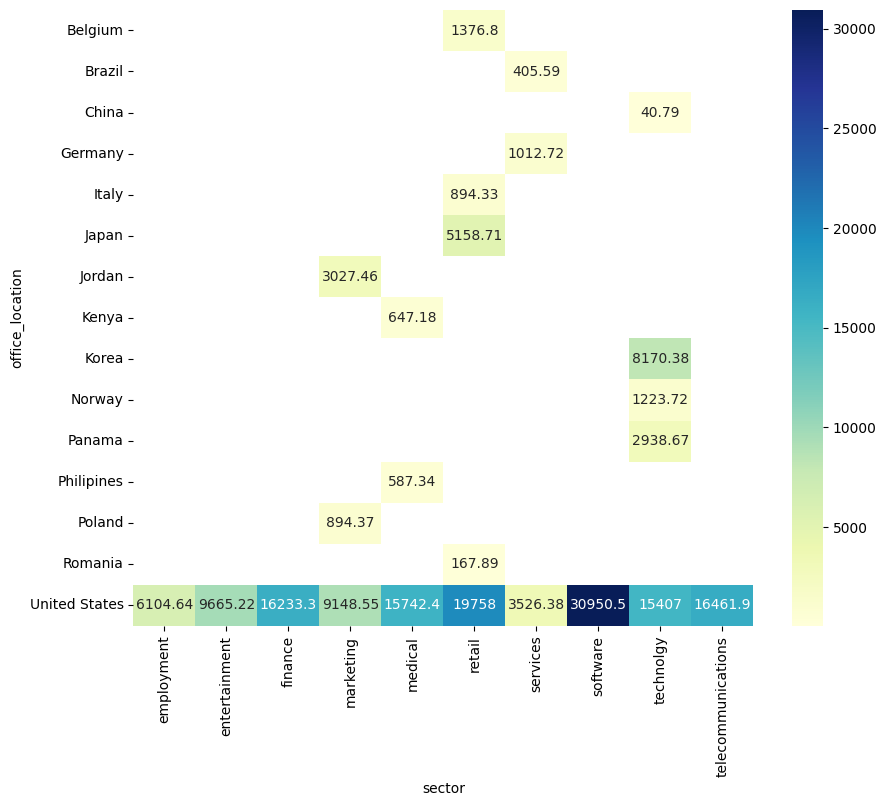

In [37]:
# Total Revenue by Sectors for all listed Countries (Account Country of Origin)
## Exploring with market potential for sales

plt.figure(figsize=(10,8))
loc_sec_rev = (acc.groupby(['office_location', 'sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
loc_sec_rev = loc_sec_rev[loc_sec_rev['revenue']!= 0]
print(loc_sec_rev)
sns.heatmap(loc_sec_rev.pivot_table(index='office_location', columns='sector', values='revenue'), annot=True, fmt='g', cmap='YlGnBu')

/tmp/ipython-input-105089109.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_sec = acc.groupby('sector').size().sort_values(ascending=False).reset_index(name='total_accounts')





--**TOTAL NUMBER OF ACCOUNTS BY SECTOR**--
               sector  total_accounts
0              retail              17
1             medical              12
2           technolgy              12
3           marketing               8
4             finance               8
5            software               7
6  telecommunications               6
7       entertainment               6
8            services               5
9          employment               4




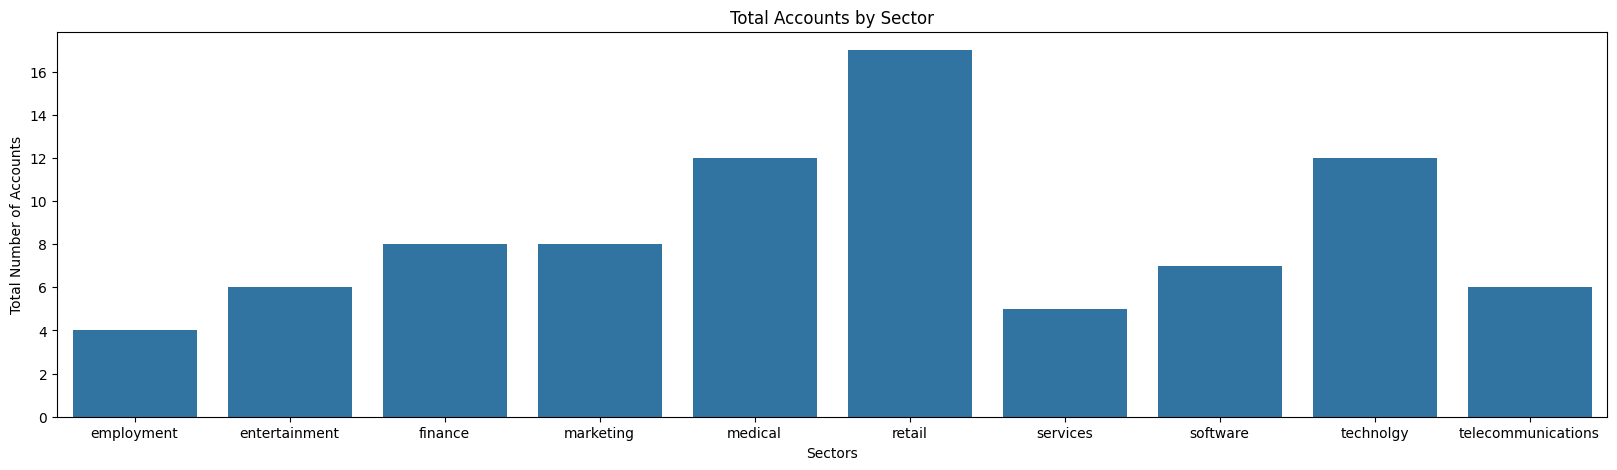

In [38]:
#1.1 Total accounts by sectors
acc_by_sec = acc.groupby('sector').size().sort_values(ascending=False).reset_index(name='total_accounts')
#print(acc['account'].value_counts())
print(f"\n\n\n--**TOTAL NUMBER OF ACCOUNTS BY SECTOR**--\n{acc_by_sec}\n\n")
plt.figure(figsize=(20,5))
sns.barplot(x="sector", y="total_accounts", data=acc_by_sec)
plt.title('Total Accounts by Sector')
plt.xlabel('Sectors')
plt.ylabel('Total Number of Accounts')
plt.show()

In [39]:
# Total Revenue for Tech sector (code trial)
acc_tech= acc[acc['sector']=="technolgy"]
round(acc_tech.revenue.sum(), 2)

np.float64(27780.53)

In [40]:
#Average and Total Revenue by Sector
rev_by_sec = acc.groupby('sector').agg({'revenue': ['sum', 'mean']}).round(2).sort_values(by=('revenue', 'sum'), ascending=False)
rev_by_sec
rev_by_sec.columns = ['total_revenue', 'average_revenue']
rev_by_sec = rev_by_sec.reset_index()
rev_by_sec = rev_by_sec.sort_values(by='total_revenue', ascending=False)
rev_by_sec

/tmp/ipython-input-3896726251.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_by_sec = acc.groupby('sector').agg({'revenue': ['sum', 'mean']}).round(2).sort_values(by=('revenue', 'sum'), ascending=False)


,sector,total_revenue,average_revenue
0,software,30950.45,4421.49
1,technolgy,27780.53,2315.04
2,retail,27355.76,1609.16
3,medical,16976.88,1414.74
4,telecommunications,16461.91,2743.65
5,finance,16233.34,2029.17
6,marketing,13070.38,1633.80
7,entertainment,9665.22,1610.87
8,employment,6104.64,1526.16
9,services,4944.69,988.94


In [41]:
# Total accounts by parent company
## Subsidiaries counted as +1 to the parent company
# Using merge function
accL = acc.copy()
print(f"\n\nLeft Table:\n{accL.head(10)}")
accR= acc.copy()
print(f"\n\nRight Table:\n{accR.head(10)}")
acc_main = accL.merge(accR, left_on='subsidiary_of', right_on='account', how='left')
print(f"\n\nMain Table:\n{acc_main.head(10)}")
'''#acc_main
#acc_main = acc.merge(acc, left_on='subsidiary_of', right_on='account', how='left')
#acc_main
#acc_main['main_acc'] = acc_main['subsidiary_of_y'].fillna(acc_main['account_x'])
#acc_main'''
acc_main['main_accn'] = acc_main['account_y'].fillna(acc_main['account_x'])
print(f"\n\nMain Table2:\n{acc_main.head(10)}")
print(acc_main['main_accn'].value_counts().sum())
acc_main['main_accn'].value_counts().to_frame().reset_index()



Left Table:
            account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation      technolgy              1996  1100.04       2822   United States  Not a Subsidiary
1        Betasoloin        medical              1999   251.41        495   United States  Not a Subsidiary
2          Betatech        medical              1986   647.18       1185           Kenya  Not a Subsidiary
3        Bioholding        medical              2012   587.34       1356      Philipines  Not a Subsidiary
4           Bioplex        medical              1991   326.82       1016   United States  Not a Subsidiary
5          Blackzim         retail              2009   497.11       1588   United States  Not a Subsidiary
6     Bluth Company      technolgy              1993  1242.32       3027   United States  Acme Corporation
7        Bubba Gump       software              2002   987.39       2253   United States  Not a Subsidiary
8           Cancity    

,main_accn,count
0,Acme Corporation,5
1,Sonron,4
2,Inity,3
3,Golddex,3
4,Bubba Gump,3
...,...,...
65,Zathunicon,1
66,Zencorporation,1
67,Zoomit,1
68,Zotware,1



***Top 10 Companies with most revenue share:

          main_accn  revenue_x
0          Kan-code   11698.03
1            Sonron    8878.44
2          Hottechi    8170.38
3             Konex    7708.38
4        Xx-holding    7537.24
5        Bubba Gump    7441.05
6  Acme Corporation    7297.05
7           Initech    6395.05
8         Ganjaflex    5158.71
9        Fasehatice    4968.91

***Companies with least revenue share:

         main_accn  revenue_x
60         Bioplex     326.82
61          Zoomit     324.19
62    Statholdings     291.27
63      Betasoloin     251.41
64    Groovestreet     223.80
65         Domzoom     217.87
66          Sumace     167.89
67      Zathunicon      71.12
68  Zencorporation      40.79
69          Condax       4.54


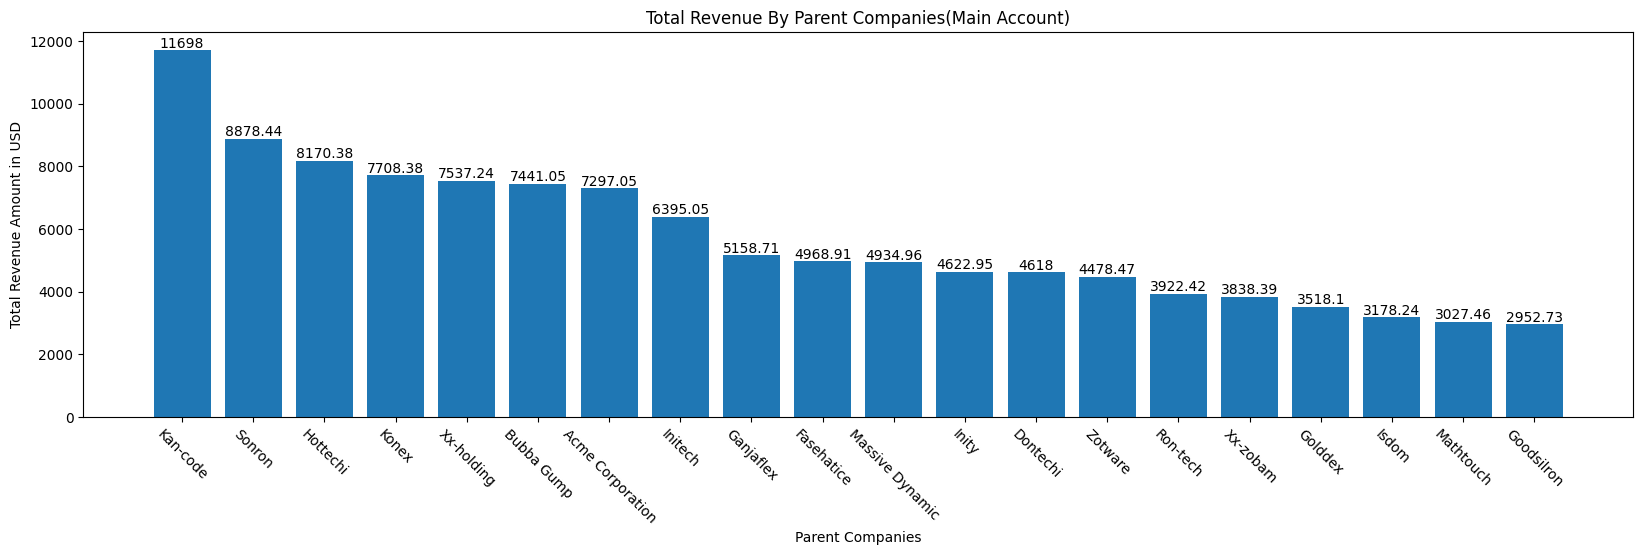

In [42]:
#Total revenue by parent companies (main account)

revenue_by_account = acc_main.groupby('main_accn')['revenue_x'].sum().sort_values(ascending=False).reset_index()
print(f"\n***Top 10 Companies with most revenue share:\n\n{revenue_by_account.head(10)}")
print(f"\n***Companies with least revenue share:\n\n{revenue_by_account.tail(10)}")


plt.figure(figsize=(20,5))
top_10_acc_rev = revenue_by_account.head(20)
figure_ax2= plt.bar(top_10_acc_rev['main_accn'], top_10_acc_rev['revenue_x'])
plt.bar_label(figure_ax2)
plt.xticks(rotation=-45)
plt.title('Total Revenue By Parent Companies(Main Account)')
plt.xlabel('Parent Companies')
plt.ylabel('Total Revenue Amount in USD')
plt.show()

In [43]:
#acc.info()

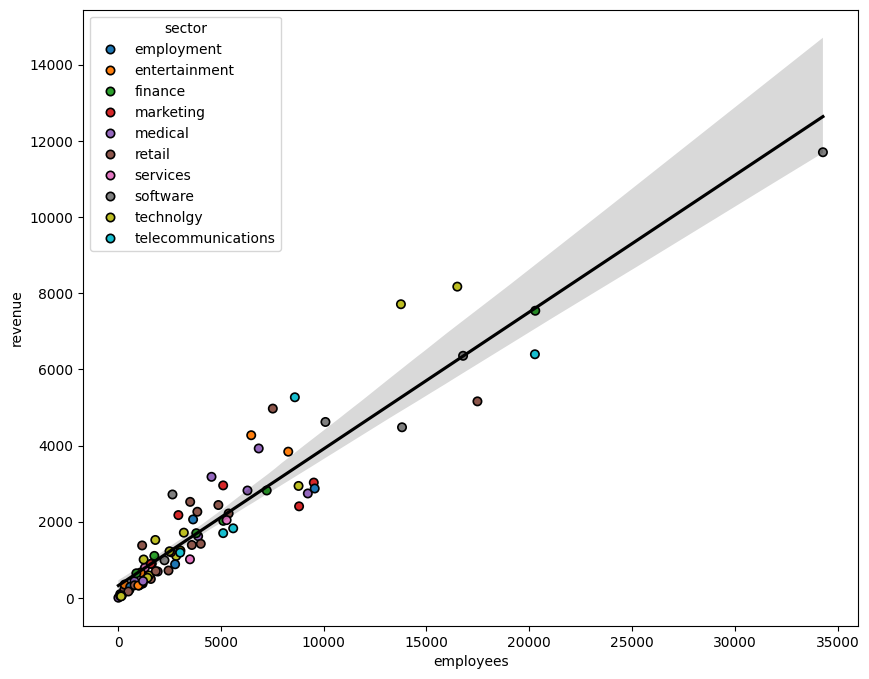



Correlation Cefficient between employees and revenue: 
[[1.         0.94608437]
 [0.94608437 1.        ]]


Coorelation between revenue and employees : 0.9460843747719687

p-value on hypothesis test: 2.1425602647004776e-42

 High correlation value >0.90 and p-value <0.05 observed. Thus we reject the null hypothesis, 
and accept the alternative, that there exists a positive correlation between employees and revenue.


In [44]:
# Correlation test + hypothestsi testing
# Null hypothesis: there's no correlation between number of employees in a company (client) and total revenue/sales generated by the company

plt.figure(figsize=(10,8))
sns.scatterplot(x=acc['employees'], y=acc['revenue'], hue=acc['sector'], palette="tab10", edgecolor="black", linewidth=1.2)
sns.regplot(x=acc['employees'], y=acc['revenue'], scatter=False, color="black")
plt.show()
#Pearson Correlation Coefficient
print(f"\n\nCorrelation Cefficient between employees and revenue: \n{np.corrcoef(acc['employees'], acc['revenue'])}")

# Using Pearson's correlation test, assuming
# 1. Equal variable pairing, 2. Each variable is continuous, 3. No Outliers, 4. Linearity and homoscedastic
x= acc['employees']
y= acc['revenue']
print(f"\n\nCoorelation between revenue and employees : {scipy.stats.pearsonr(x,y)[0]}")
print(f"\np-value on hypothesis test: {scipy.stats.pearsonr(x,y)[1]}")
print("\n High correlation value >0.90 and p-value <0.05 observed. Thus we reject the null hypothesis, \nand accept the alternative, that there exists a positive correlation between employees and revenue.")


In [45]:
# Based on company's year of establishment, comparing their sales/revenue generated.
## This will provide us with an idea if legacy companies (established), are generateing more revenue than the newly formed start-ups or ventures

#acc['year_established'].value_counts().sort_index(ascending=True)

rev_year = acc.groupby(['year_established'])['revenue'].sum().reset_index()
rev_year = rev_year.sort_values(by='revenue', ascending=False)
rev_year.head(10)

,year_established,revenue
2,1982,17108.49
13,1993,13695.56
17,1997,11385.50
14,1994,10757.08
16,1996,10109.06
15,1995,9490.94
8,1988,8702.79
1,1980,7708.38
10,1990,7489.74
12,1992,5959.29


Legacy companies (here, pre 1998) generate revenue 
above-avg revenue, in contrast to the newly established companies 
which generate lesser revenue and contribute to lower 
sales


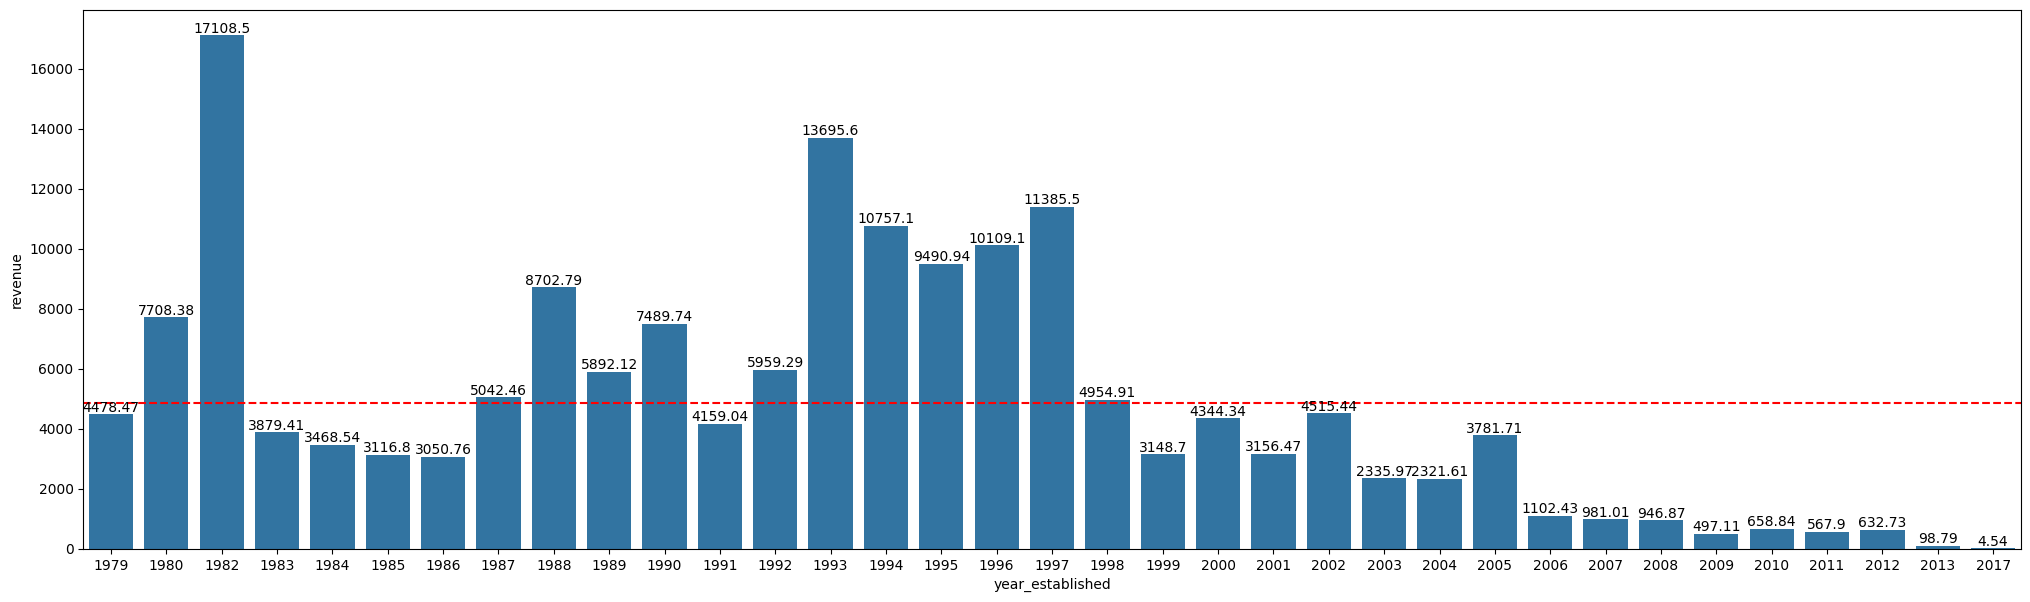

In [46]:
plt.figure(figsize=(25,7))
avg_year_rev = rev_year['revenue'].mean()
ax_figue1 = sns.barplot(x='year_established', y='revenue', data= rev_year)
print("Legacy companies (here, pre 1998) generate revenue \nabove-avg revenue, in contrast to the newly established companies \nwhich generate lesser revenue and contribute to lower \nsales")
ax_figue1.bar_label(ax_figue1.containers[0])
plt.axhline(y=avg_year_rev, color='red', linestyle='--', label=avg_year_rev)

/tmp/ipython-input-3156329529.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = acc.pivot_table(index='year_established', columns='sector', values='revenue', aggfunc='sum', fill_value=0)


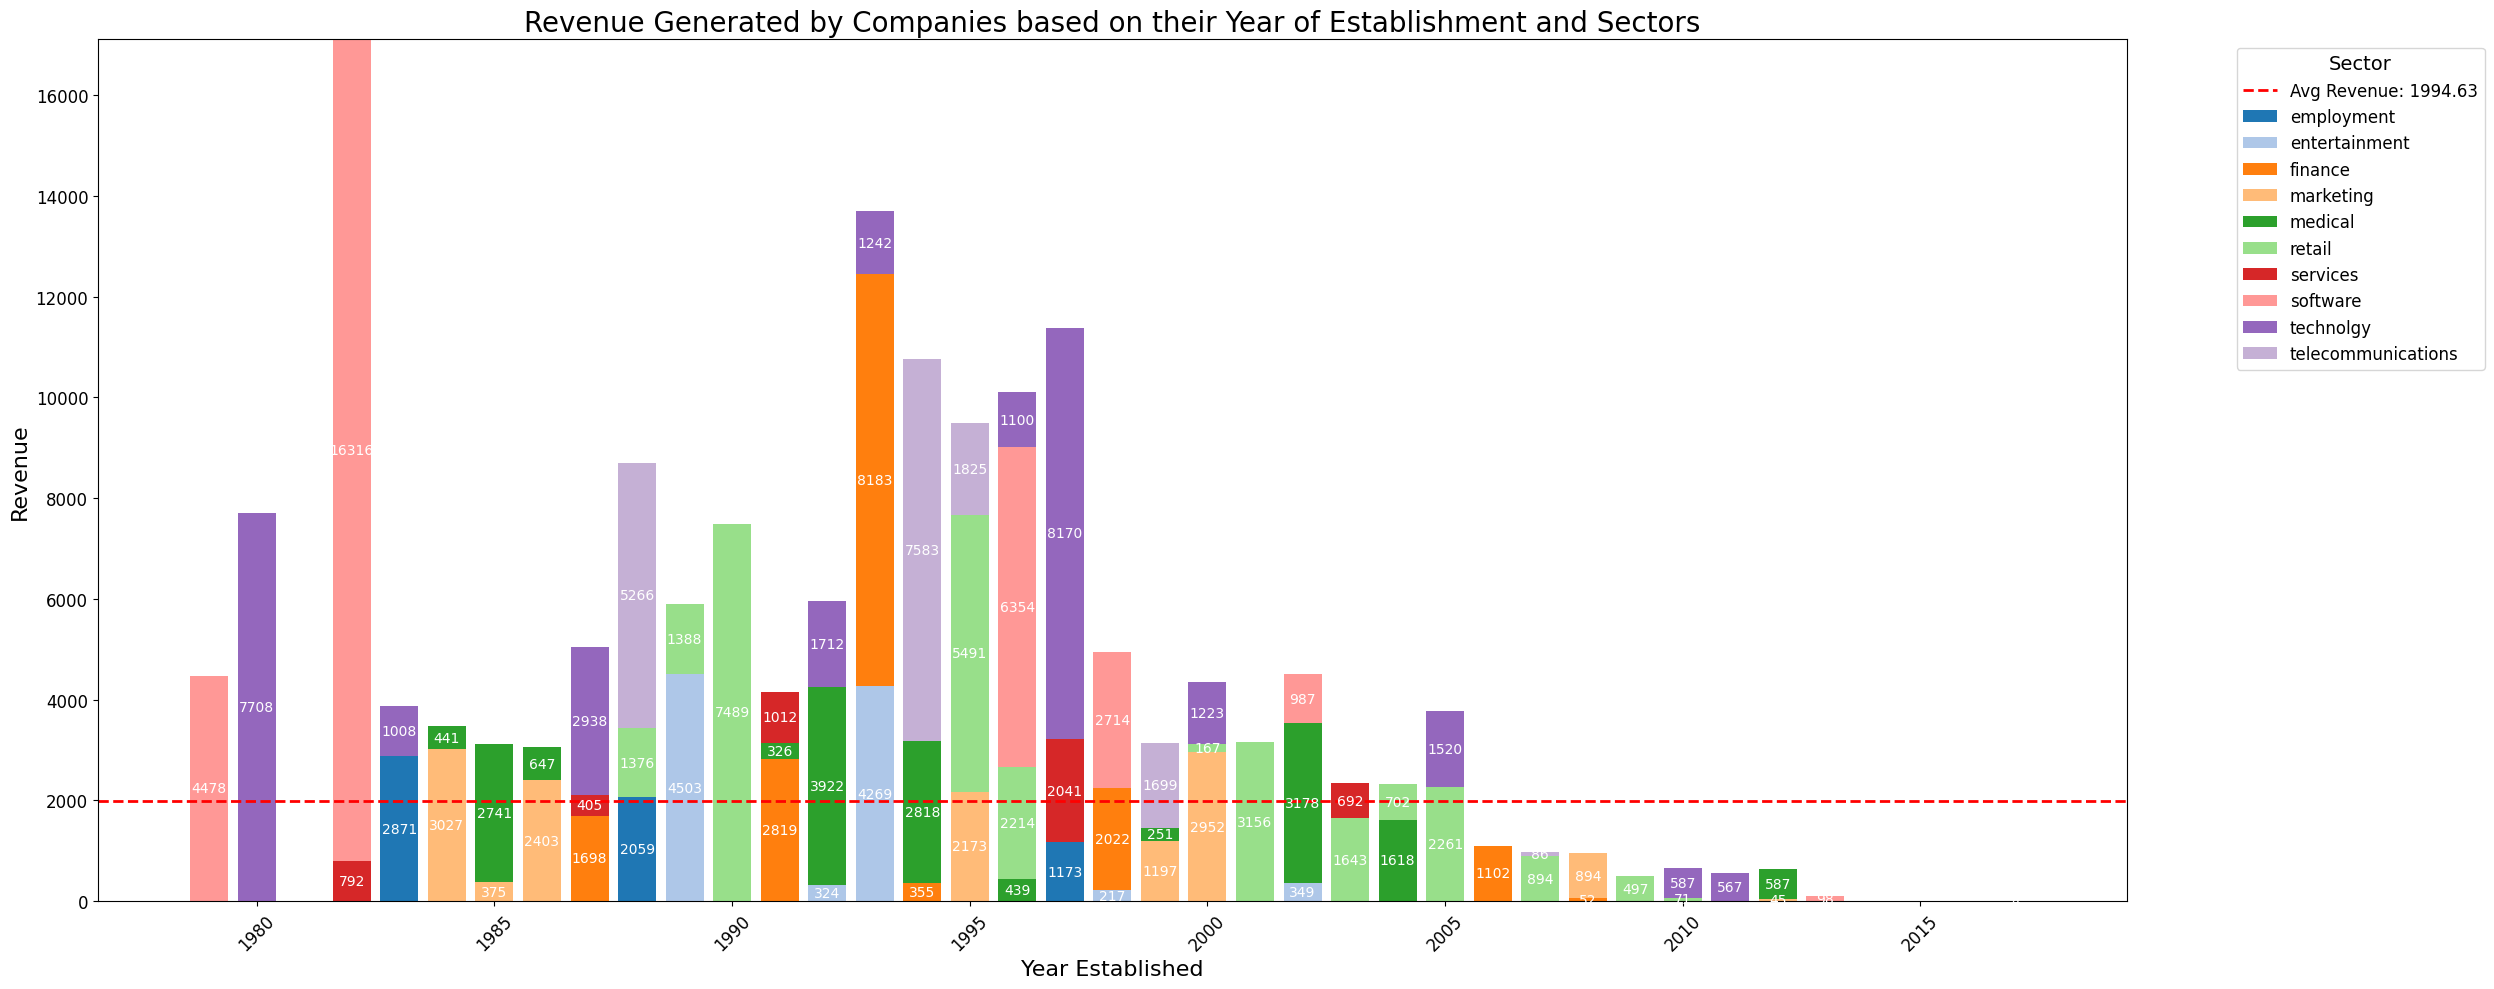

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot data
pivot_df = acc.pivot_table(index='year_established', columns='sector', values='revenue', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(25,10))

bottom = np.zeros(len(pivot_df))
colors = plt.cm.tab20.colors
sector_list = pivot_df.columns.tolist()

# Plot each sector individually and add labels
for i, sector in enumerate(sector_list):
    bars = ax.bar(pivot_df.index, pivot_df[sector], bottom=bottom, label=sector, color=colors[i % len(colors)])

    # Add labels inside each bar segment
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # avoid labeling zero-height segments
            ax.text(
                bar.get_x() + bar.get_width()/2,      # X position: center of the bar
                bar.get_y() + height/2,               # Y position: middle of the segment
                f'{int(height)}',                      # Label text
                ha='center',
                va='center',
                fontsize=10,
                color='white'                          # white text for contrast
            )
    bottom += pivot_df[sector].values  # update bottom for stacking

# Average revenue line
avg_year_rev = acc['revenue'].mean()
ax.axhline(y=avg_year_rev, color='red', linestyle='--', linewidth=2, label=f'Avg Revenue: {avg_year_rev:.2f}')

# Labels and title
ax.set_xlabel('Year Established', fontsize=16)
ax.set_ylabel('Revenue', fontsize=16)
ax.set_title('Revenue Generated by Companies based on their Year of Establishment and Sectors', fontsize=20)

# Legend
ax.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

               sector  total_revenue  average_revenue
0            software       30950.45          4421.49
1           technolgy       27780.53          2315.04
2              retail       27355.76          1609.16
3             medical       16976.88          1414.74
4  telecommunications       16461.91          2743.65
5             finance       16233.34          2029.17
6           marketing       13070.38          1633.80
7       entertainment        9665.22          1610.87
8          employment        6104.64          1526.16
9            services        4944.69           988.94


Avg Revenue Overall = 2029.3



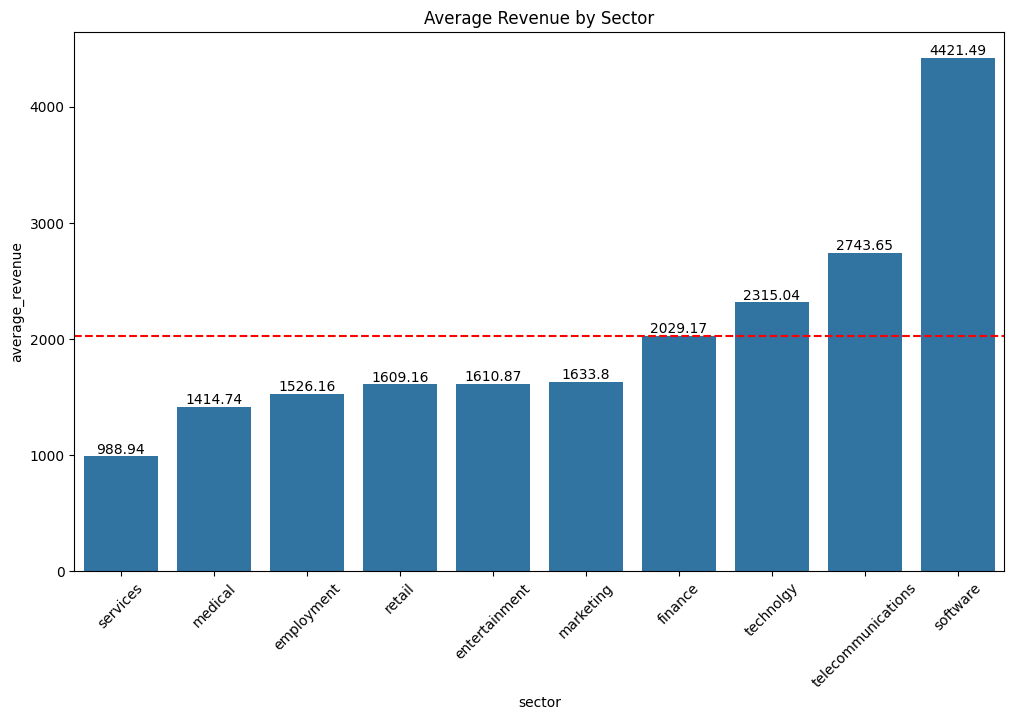

In [48]:
# Average and Total Revenue Generated by Sectors

print(rev_by_sec)

#Average Revenue Generated by Sectors


#Adding an avg line
avg_rev_accn = rev_by_sec['average_revenue'].mean().round(2)
print(f"\n\nAvg Revenue Overall = {avg_rev_accn}\n")

#bar plot with avg line
plt.figure(figsize=(12,7))
ax = sns.barplot(
    data=rev_by_sec,
    x='sector',
    y='average_revenue',
    order=rev_by_sec.sort_values(by="average_revenue", ascending = True)['sector']
)
plt.title('Average Revenue by Sector')
ax.bar_label(ax.containers[0])
plt.axhline(y=avg_rev_accn, color='red', linestyle='--', label=avg_rev_accn)
plt.xticks(rotation=45)  # if sector names are long
plt.show()


In [49]:
#View data
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


In [50]:
#total accounts for each country, the total revenue generate, and their market share
'''
result10 = acc.groupby('office_location')['account'].count().reset_index()
result10.columns = ['office_location', 'total_accounts']
result10.sort_values(by='total_accounts', ascending=False)
result10['total_revenue'] = acc.groupby('office_location')['revenue'].sum().reset_index()['revenue']
result10 = result10.sort_values(by='total_revenue', ascending= False)
result10['revenue_share'] = result10['total_revenue']/result10['total_revenue'].sum()
result10['revenue_share'] = result10['revenue_share'].round(2)
result10'''

"\nresult10 = acc.groupby('office_location')['account'].count().reset_index()\nresult10.columns = ['office_location', 'total_accounts']\nresult10.sort_values(by='total_accounts', ascending=False)\nresult10['total_revenue'] = acc.groupby('office_location')['revenue'].sum().reset_index()['revenue']\nresult10 = result10.sort_values(by='total_revenue', ascending= False)\nresult10['revenue_share'] = result10['total_revenue']/result10['total_revenue'].sum()\nresult10['revenue_share'] = result10['revenue_share'].round(2)\nresult10"

In [51]:
#Total Accounts For Each Country, The Total Revenue Generate, And Their Market Share

result10 = acc.groupby('office_location')['account'].count().reset_index()
result10.columns = ['office_location', 'total_accounts']

total_revenue = acc.groupby('office_location')['revenue'].sum().reset_index()
total_revenue = total_revenue.rename(columns={'revenue':'total_revenue'})

result10 = pd.merge(result10, total_revenue, on='office_location')
result10['revenue_share'] = (result10['total_revenue'] / result10['total_revenue'].sum()).round(2)

result10 = result10.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)
result10

,office_location,total_accounts,total_revenue,revenue_share
0,United States,71,142997.85,0.84
1,Korea,1,8170.38,0.05
2,Japan,1,5158.71,0.03
3,Jordan,1,3027.46,0.02
4,Panama,1,2938.67,0.02
5,Belgium,1,1376.80,0.01
6,Norway,1,1223.72,0.01
7,Germany,1,1012.72,0.01
8,Poland,1,894.37,0.01
9,Italy,1,894.33,0.01


In [52]:
#Most recently created accounts, which market do they belong to, their office location, associating parent company, and the amount of total revenue generated

result20 = acc.groupby(['year_established', 'account', 'office_location', 'subsidiary_of']).agg({'revenue': 'sum'}).reset_index()
result20.columns = ['year_established', 'account', 'office_location','parent_company','total_revenue']
result20 = result20.sort_values(by='year_established', ascending=False)
result20 = result20.sort_values(['year_established', 'total_revenue'], ascending=[False, False])
result20

,year_established,account,office_location,parent_company,total_revenue
84,2017,Condax,United States,Not a Subsidiary,4.54
83,2013,Dalttechnology,United States,Bubba Gump,98.79
81,2012,Bioholding,Philipines,Not a Subsidiary,587.34
82,2012,Scottech,United States,Inity,45.39
79,2011,Iselectrics,United States,Acme Corporation,527.11
...,...,...,...,...,...
4,1982,Kan-code,United States,Not a Subsidiary,11698.03
2,1982,Dontechi,United States,Not a Subsidiary,4618.00
3,1982,Hatfan,United States,Not a Subsidiary,792.46
1,1980,Konex,United States,Not a Subsidiary,7708.38


In [53]:
#Adding sector to the above table
result20 = acc.groupby(['year_established', 'account', 'office_location', 'subsidiary_of']) \
              .agg({'revenue':'sum'}) \
              .reset_index()
result20 = pd.merge(result20, acc[['account','sector']].drop_duplicates(), on='account', how='left')
result20.columns = ['year_established', 'account', 'office_location','parent_company','total_revenue','sector']
result20 = result20.sort_values(['year_established', 'total_revenue'], ascending=[False, False])
result20

,year_established,account,office_location,parent_company,total_revenue,sector
84,2017,Condax,United States,Not a Subsidiary,4.54,medical
83,2013,Dalttechnology,United States,Bubba Gump,98.79,software
81,2012,Bioholding,Philipines,Not a Subsidiary,587.34,medical
82,2012,Scottech,United States,Inity,45.39,marketing
79,2011,Iselectrics,United States,Acme Corporation,527.11,technolgy
...,...,...,...,...,...,...
4,1982,Kan-code,United States,Not a Subsidiary,11698.03,software
2,1982,Dontechi,United States,Not a Subsidiary,4618.00,software
3,1982,Hatfan,United States,Not a Subsidiary,792.46,services
1,1980,Konex,United States,Not a Subsidiary,7708.38,technolgy


In [54]:
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


## Sales Pipeline

In [55]:
sales_pipe.head(10)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won
5,ZNBS69V1,Anna Snelling,MG Special,Ron-tech,Won,2016-10-29,2017-03-01,49.0,Won
6,9ME3374G,Vicki Laflamme,MG Special,J-Texon,Won,2016-10-30,2017-03-02,57.0,Won
7,7GN8Q4LL,Markita Hansen,GTX Basic,Cheers,Won,2016-11-01,2017-03-07,601.0,Won
8,OLK9LKZB,Niesha Huffines,GTX Plus Basic,Zumgoity,Won,2016-11-01,2017-03-03,1026.0,Won
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaT,NaN,Engaging


1490.9155118462227


Text(0.5, 1.0, 'Closed Sales/Deals Over the Year')

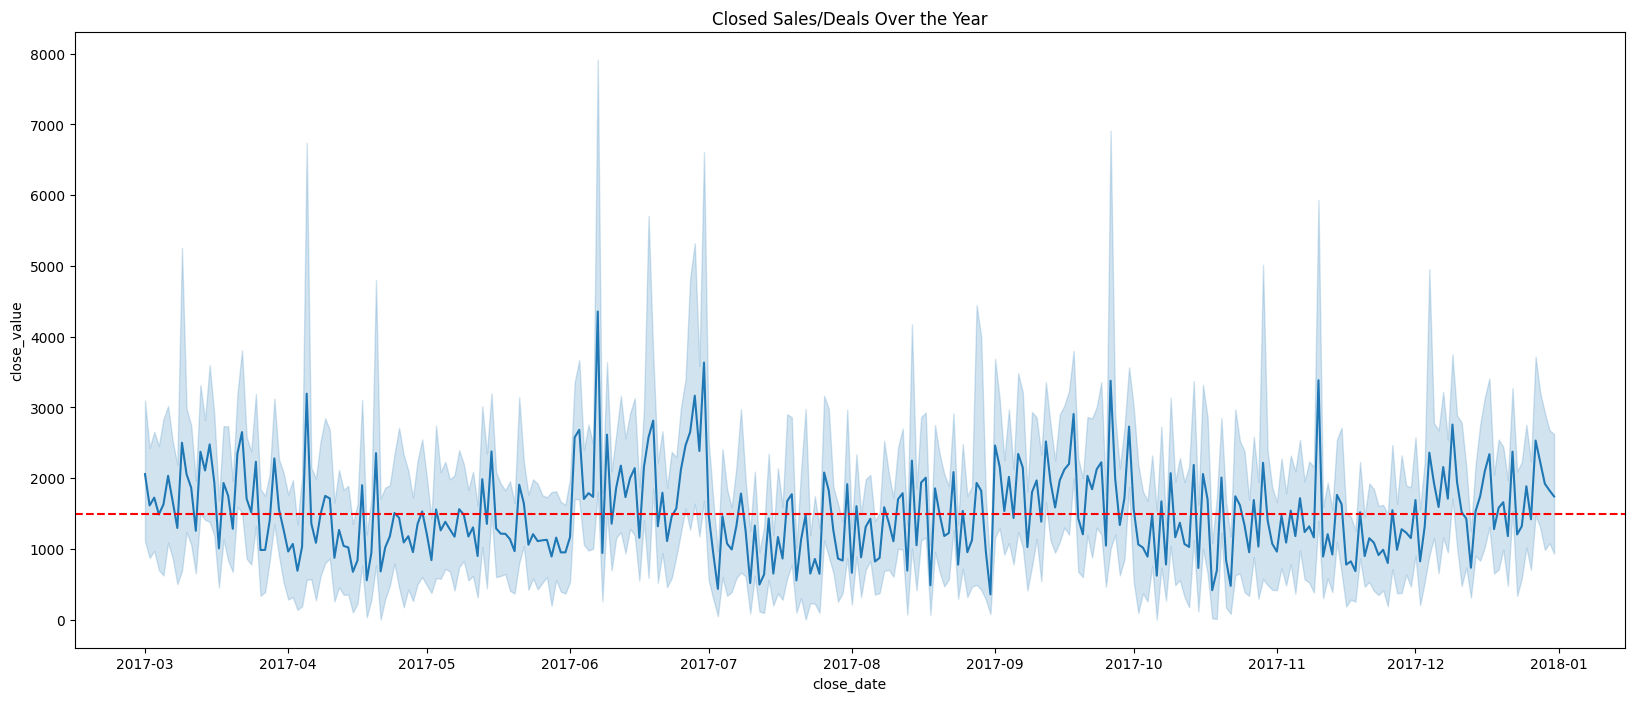

In [56]:
plt.figure(figsize=(20,8))
mean_monthly_close_value = sales_pipe['close_value'].mean()
print(mean_monthly_close_value)

ax=sns.lineplot(x='close_date', y='close_value', data=sales_pipe)
plt.axhline(y=mean_monthly_close_value, color='red', linestyle='--', label=mean_monthly_close_value)
ax.set_title("Closed Sales/Deals Over the Year")

In [57]:
# Total Monthly Sales Generated

sales_pipe['close_date'] = pd.to_datetime(sales_pipe['close_date'])
sales_pipe['close_date'] = sales_pipe['close_date'].dt.to_period('M').astype(str)
sales_pipe['engage_date'] = pd.to_datetime(sales_pipe['engage_date'])

monthly_sales = sales_pipe.groupby('close_date', as_index=False)['close_value'].sum()
monthly_sales = monthly_sales.sort_values(by='close_date', ascending=True)
monthly_sales = monthly_sales[monthly_sales['close_date']!= 'NaT']
monthly_sales

,close_date,close_value
0,2017-03,1134672.0
1,2017-04,721932.0
2,2017-05,1025713.0
3,2017-06,1338466.0
4,2017-07,696932.0
5,2017-08,1050059.0
6,2017-09,1235264.0
7,2017-10,731980.0
8,2017-11,938943.0
9,2017-12,1131573.0


Mean of Total Monthly Sales = 1000553.4


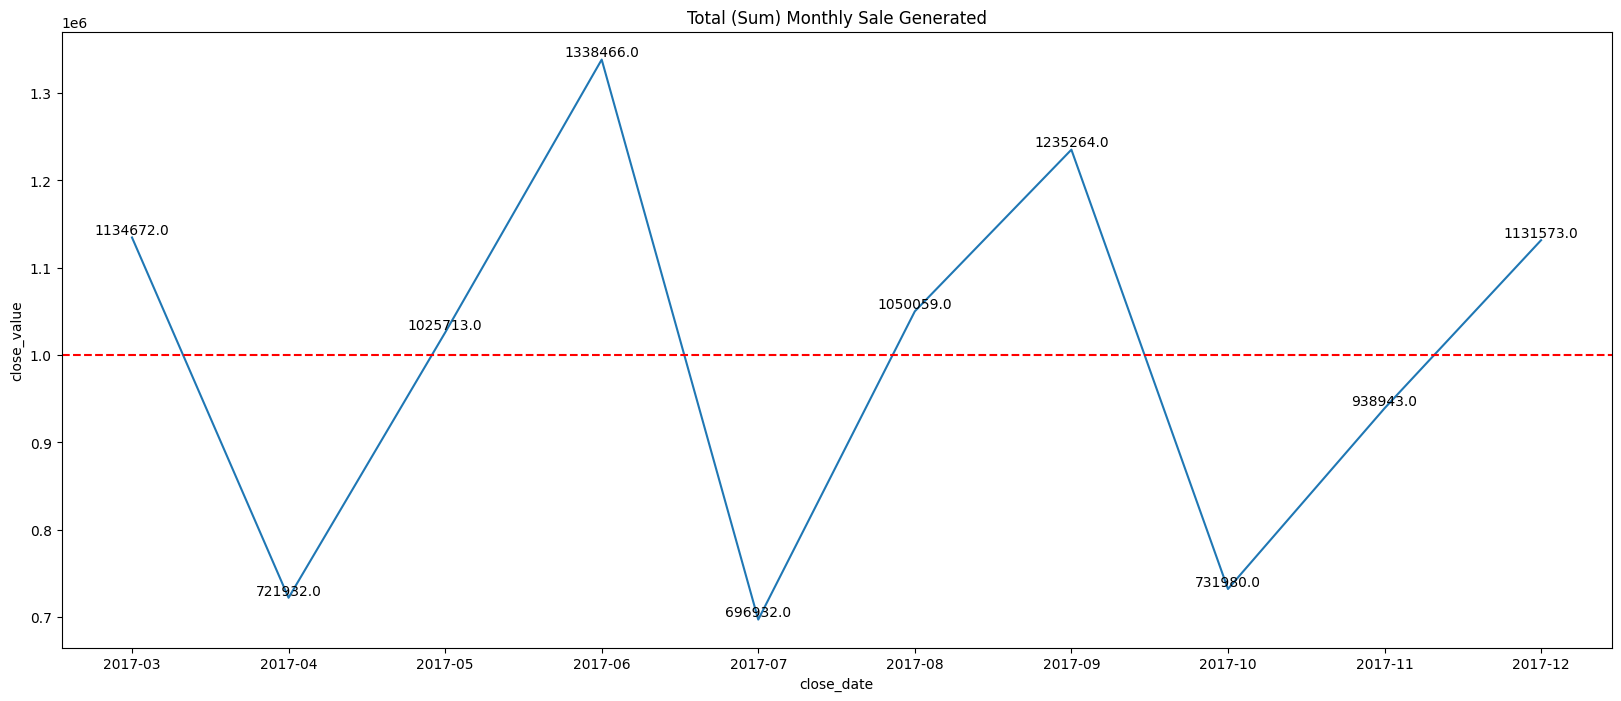

In [58]:
#Total (Sum) Revenue Generated, Monthly

plt.figure(figsize=(20,8))
ax=sns.lineplot(x='close_date', y='close_value', data=monthly_sales)
ax.set_title("Total (Sum) Monthly Sale Generated")

mean_total_monthly_sales = monthly_sales['close_value'].mean()
print(f"Mean of Total Monthly Sales = {mean_total_monthly_sales}")
ax.axhline(y=mean_total_monthly_sales, color='red', linestyle='--', label=mean_total_monthly_sales)

for x, y in zip(monthly_sales['close_date'], monthly_sales['close_value']):
    ax.text(x, y, str(y), ha='center', va='bottom', fontsize=10, color ='black')

In [59]:
sales_pipe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   opportunity_id  8800 non-null   object        
 1   sales_agent     8800 non-null   object        
 2   product         8800 non-null   object        
 3   account         7375 non-null   object        
 4   deal_stage      8800 non-null   object        
 5   engage_date     8300 non-null   datetime64[ns]
 6   close_date      8800 non-null   object        
 7   close_value     6711 non-null   float64       
 8   deal_satge      8800 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(1), object(6)
memory usage: 558.9+ KB


In [89]:
# Calculating Total Days Engaged to Close a Sale/Deal

sales_pipe['close_date'] = pd.to_datetime(sales_pipe['close_date'])
sales_pipe['engage_date'] = pd.to_datetime(sales_pipe['engage_date'])

sales_pipe['total_days_engaged'] = sales_pipe['close_date'] - sales_pipe['engage_date']
sales_pipe['total_days_engaged'] = sales_pipe['total_days_engaged'].dt.days
sales_pipe

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,total_days_engaged
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-01,4514.0,Won,127.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-01,50.0,Won,127.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-01,588.0,Won,127.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-01,517.0,Won,127.0
...,...,...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting,NaN
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting,NaN
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting,NaN
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting,NaN


In [102]:
# Classify the total number of opportunities by deal stages, average days involved, and % ratios of the deals

resulta = sales_pipe.groupby('deal_stage')['opportunity_id'].count().reset_index()
resulta = resulta.sort_values(by= 'deal_stage', ascending=False)
print(f"{resulta}\n\n")
resulta1 = sales_pipe.groupby('deal_stage')['total_days_engaged'].mean().round(2).reset_index()
resulta1 = resulta1.sort_values(by= 'deal_stage', ascending=False)
print(f"{resulta1}\n\n")

resulta2 = pd.merge(resulta, resulta1, on ='deal_stage')
resulta2['total_oppor'] = resulta2['opportunity_id'].sum()
resulta2['deal_ratio'] = resulta2['opportunity_id']/resulta2['total_oppor']
resulta2['deal_ratio'] = resulta2['deal_ratio'].round(2)
resulta2

resulta2 = resulta2.rename(columns={'opportunity_id':'deal_opportunities', 'total_days_engaged':'avg_days_engaged'})
print(resulta2)

# Total Days Engaged

sales_pipe_won_lost_time = sales_pipe[sales_pipe['deal_stage'].isin(['Won','Lost'])]
print(f"\n\n{sales_pipe_won_lost_time}")
negative_durations = sales_pipe_won_lost_time[sales_pipe_won_lost_time['total_days_engaged'] < 0]
negative_durations

    deal_stage  opportunity_id
3          Won            4238
2  Prospecting             500
1         Lost            2473
0     Engaging            1589


    deal_stage  total_days_engaged
3          Won               36.90
2  Prospecting                 NaN
1         Lost               26.63
0     Engaging                 NaN


    deal_stage  deal_opportunities  avg_days_engaged  total_oppor  deal_ratio
0          Won                4238             36.90         8800        0.48
1  Prospecting                 500               NaN         8800        0.06
2         Lost                2473             26.63         8800        0.28
3     Engaging                1589               NaN         8800        0.18


     opportunity_id       sales_agent         product        account deal_stage engage_date close_date  close_value deal_satge  total_days_engaged
0          1C1I7A6R       Moses Frase  GTX Plus Basic        Cancity        Won  2016-10-20 2017-03-01       1054.0        Won 

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,total_days_engaged
1223,G20IQSA3,Anna Snelling,GTX Basic,Conecom,Won,2017-03-02,2017-03-01,522.0,Won,-1.0
1224,Q16BQCEL,Boris Faz,GTX Plus Basic,Kinnamplus,Won,2017-03-02,2017-03-01,1001.0,Won,-1.0
1234,VBZ862OS,Kary Hendrixson,GTX Basic,Xx-holding,Won,2017-03-02,2017-03-01,599.0,Won,-1.0
1242,DB3N4CHN,Versie Hillebrand,MG Special,Hottechi,Won,2017-03-02,2017-03-01,62.0,Won,-1.0
1246,OF7GY5F4,Violet Mclelland,MG Special,The New York Inquirer,Won,2017-03-02,2017-03-01,61.0,Won,-1.0
...,...,...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-01,622.0,Won,-23.0
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-01,1093.0,Won,-23.0
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-01,4433.0,Won,-25.0
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-01,1052.0,Won,-26.0


In [62]:
# deal stages counts and action rate (%Won, %Lost, % Prospecting, %Engaging ) for each sales agent, and their success rate
resultb1 = sales_pipe.groupby(['sales_agent', 'deal_stage'])['opportunity_id'].count().reset_index()
resultsb2 = resultb1.sort_values(['sales_agent', 'opportunity_id'], ascending=[True, False])
resultsb2['total_opportunities'] = resultsb2.groupby(['sales_agent'])['opportunity_id'].transform('sum')
resultsb2['action rate'] = resultsb2['opportunity_id']/resultsb2['total_opportunities']
resultsb2['action rate'] = resultsb2['action rate'].round(2)
resultsb2

,sales_agent,deal_stage,opportunity_id,total_opportunities,action rate
3,Anna Snelling,Won,208,448,0.46
1,Anna Snelling,Lost,128,448,0.29
0,Anna Snelling,Engaging,57,448,0.13
2,Anna Snelling,Prospecting,55,448,0.12
6,Boris Faz,Won,101,210,0.48
...,...,...,...,...,...
91,Wilburn Farren,Engaging,31,110,0.28
92,Wilburn Farren,Lost,24,110,0.22
96,Zane Levy,Won,161,349,0.46
95,Zane Levy,Lost,100,349,0.29


<Axes: xlabel='deal_stage', ylabel='sales_agent'>

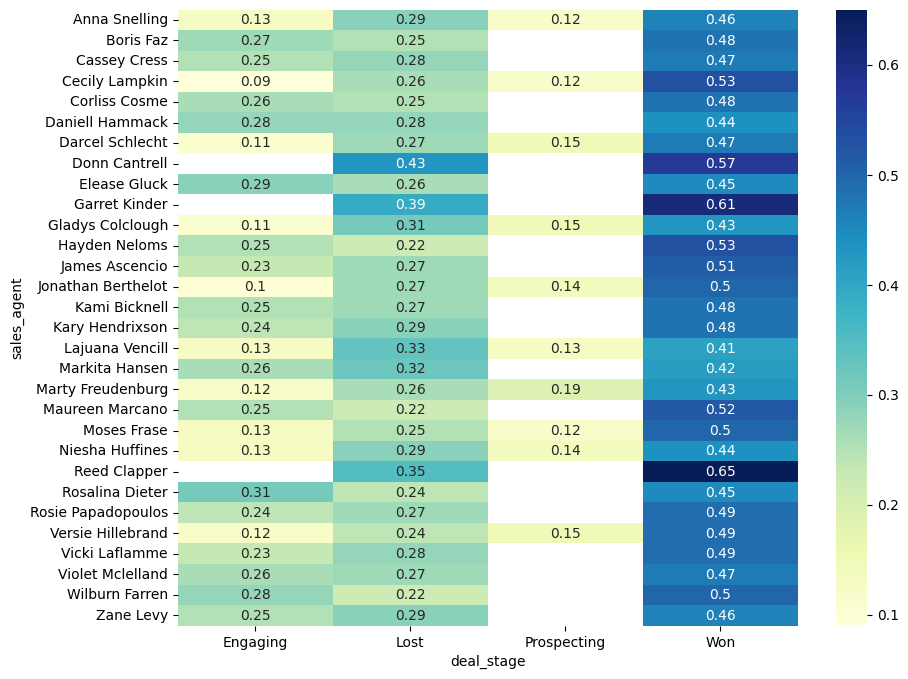

In [63]:
#Heat map of sales agent and the action rates based on deal stages
plt.figure(figsize=(10,8))
sns.heatmap(resultsb2.pivot_table(index='sales_agent', columns='deal_stage', values='action rate'), annot=True, fmt='g', cmap='YlGnBu')

In [64]:
# opportunities for each sales agent classified by products  total number of wins, loses, engagement, and prospecting

resultc1 = sales_pipe.groupby(['sales_agent', 'product', 'deal_stage'])['opportunity_id'].count().reset_index()
resultc1 = resultc1.sort_values(['sales_agent', 'opportunity_id'], ascending=[True, False])
#resultc1
resultc1['total_opportunities'] = resultc1.groupby(['sales_agent'])['opportunity_id'].transform('sum')
resultc1['action_rate'] = resultc1['opportunity_id']/resultc1['total_opportunities']
resultc1['action_rate'] = resultc1['action_rate'].round(2)
resultc1 = resultc1.sort_values(['sales_agent', 'action_rate'], ascending=[True, False])
resultc1

# splitting the dataset based on deal stages Won&Lost, Engaging, and Prospecting
resultc_wl = resultc1[resultc1['deal_stage'].isin(['Won', 'Lost'])]
resultc_wl

,sales_agent,product,deal_stage,opportunity_id,total_opportunities,action_rate
19,Anna Snelling,MG Special,Won,102,448,0.23
17,Anna Snelling,MG Special,Lost,42,448,0.09
3,Anna Snelling,GTX Basic,Won,32,448,0.07
11,Anna Snelling,GTX Plus Pro,Won,28,448,0.06
7,Anna Snelling,GTX Plus Basic,Won,25,448,0.06
...,...,...,...,...,...,...
553,Zane Levy,GTX Plus Pro,Lost,11,349,0.03
560,Zane Levy,MG Advanced,Won,10,349,0.03
562,Zane Levy,MG Special,Lost,10,349,0.03
563,Zane Levy,MG Special,Won,10,349,0.03


In [65]:
sales_pipe.head(10)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,total_days_engaged
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-01,4514.0,Won,127.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-01,50.0,Won,127.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-01,588.0,Won,127.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-01,517.0,Won,127.0
5,ZNBS69V1,Anna Snelling,MG Special,Ron-tech,Won,2016-10-29,2017-03-01,49.0,Won,123.0
6,9ME3374G,Vicki Laflamme,MG Special,J-Texon,Won,2016-10-30,2017-03-01,57.0,Won,122.0
7,7GN8Q4LL,Markita Hansen,GTX Basic,Cheers,Won,2016-11-01,2017-03-01,601.0,Won,120.0
8,OLK9LKZB,Niesha Huffines,GTX Plus Basic,Zumgoity,Won,2016-11-01,2017-03-01,1026.0,Won,120.0
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaT,NaN,Engaging,NaN


In [66]:
#Based on products, who is the best seller?

#First getting the total closed value for each product, and the number of units sold
resultd1 = sales_pipe.groupby(['product'])['close_value'].sum().reset_index()
resultd1 = resultd1.sort_values(by='close_value', ascending=False)
print(f"Total Revenue generated by selling each product in the line up:\n\n{resultd1}")

resultd2 = (sales_pipe[sales_pipe['deal_stage'] == "Won"].groupby(['product', 'deal_stage']).size().reset_index(name='deals_won'))
resultd2 = resultd2.sort_values(by='deals_won', ascending=False)
print(f"\n\n\nTotal number of units sold a.k.a deals won:\n\n{resultd2}")

resultd3 = pd.merge(resultd1, resultd2, on='product', how='left')
print(f"\n\n\nMerging Total Revenue and Total Units Sold:\n\n{resultd3}")

#Total number of deals for each product

resultd4 = sales_pipe[sales_pipe['deal_stage'].isin(['Won', 'Lost'])].groupby('product')['opportunity_id'].count().reset_index()
resultd4 = resultd4.sort_values(by='opportunity_id', ascending=False)
print(f"\n\n\nTotal Number of opportunities Won and Lost for each product:\n\n{resultd4}")

#Just for reference, how many won and lost for each prooduct
resultd5 = sales_pipe[sales_pipe['deal_stage'].isin(['Won', 'Lost'])]
resultd5 = resultd5.groupby(['product', 'deal_stage'])['opportunity_id'].count().reset_index()
resultd5['total_units'] = resultd5.groupby('product')['opportunity_id'].transform('sum')
resultd5 = resultd5.pivot_table(
    index = 'product',
    columns='deal_stage',
    values='opportunity_id'
).reset_index()
resultd5['Total_opportunities'] = resultd5['Won'] + resultd5['Lost']
resultd5['Won_rate'] = (resultd5['Won']/resultd5['Total_opportunities']).round(2)
resultd5 = resultd5.sort_values(by='Total_opportunities', ascending=False)
print(f"\n\n {resultd5}")

Total Revenue generated by selling each product in the line up:

          product  close_value
4          GTXPro    3510578.0
3    GTX Plus Pro    2629651.0
5     MG Advanced    2216387.0
2  GTX Plus Basic     705275.0
1       GTX Basic     499263.0
0         GTK 500     400612.0
6      MG Special      43768.0



Total number of units sold a.k.a deals won:

          product deal_stage  deals_won
1       GTX Basic        Won        915
6      MG Special        Won        793
4          GTXPro        Won        729
5     MG Advanced        Won        654
2  GTX Plus Basic        Won        653
3    GTX Plus Pro        Won        479
0         GTK 500        Won         15



Merging Total Revenue and Total Units Sold:

          product  close_value deal_stage  deals_won
0          GTXPro    3510578.0        Won        729
1    GTX Plus Pro    2629651.0        Won        479
2     MG Advanced    2216387.0        Won        654
3  GTX Plus Basic     705275.0        Won        653
4     

In [67]:
resultd6 = pd.merge(resultd3, resultd5, on = 'product', how='left')
convt_to_int = ['Won', 'Lost', 'Total_opportunities']
for col in convt_to_int:
    resultd6[col] = resultd6[col].astype(int)
resultd6

,product,close_value,deal_stage,deals_won,Lost,Won,Total_opportunities,Won_rate
0,GTXPro,3510578.0,Won,729,418,729,1147,0.64
1,GTX Plus Pro,2629651.0,Won,479,266,479,745,0.64
2,MG Advanced,2216387.0,Won,654,430,654,1084,0.60
3,GTX Plus Basic,705275.0,Won,653,398,653,1051,0.62
4,GTX Basic,499263.0,Won,915,521,915,1436,0.64
5,GTK 500,400612.0,Won,15,10,15,25,0.60
6,MG Special,43768.0,Won,793,430,793,1223,0.65


In [68]:
resulte1 = sales_pipe[sales_pipe['deal_stage']=='Won']
resulte1.head(10)
# Sales poople with total opportunities for each product
#resulte2 = resulte1.groupby('product')['sales_agent'].count().sort_values(ascending=False).reset_index()
#resulte2.columns = ['product', 'total_sales_agents']
#print(f"Number of sales agent for each product:\n\n{resulte2}")

#Top sales agent for each product and the amount of sales and units sold by them
resulte3 = resulte1.groupby(['product', 'sales_agent'])['opportunity_id'].count().reset_index(name= 'Total_Units_Sold')
resulte3 = resulte3.sort_values(by=['product', 'Total_Units_Sold'], ascending= [True, False])
resulte3['max_units_sold'] = resulte3.groupby('product')['Total_Units_Sold'].transform('max')

top_agents_per_product = resulte3[resulte3['Total_Units_Sold'] == resulte3['max_units_sold']]
print(f"\n\nTop Agents with highest units sold for each product: \n{top_agents_per_product}")



Top Agents with highest units sold for each product: 
            product        sales_agent  Total_Units_Sold  max_units_sold
0           GTK 500       Elease Gluck                 7               7
17        GTX Basic    Kary Hendrixson                82              82
38   GTX Plus Basic    Darcel Schlecht                56              56
74     GTX Plus Pro     James Ascencio                44              44
96           GTXPro    Darcel Schlecht               160             160
127     MG Advanced      Hayden Neloms                59              59
171      MG Special  Versie Hillebrand               117             117


In [69]:
# Counts and Revenue
resulte3 = (
    resulte1
    .groupby(['product', 'sales_agent']).agg(Total_Units_Sold=('opportunity_id', 'count'), Total_Revenue=('close_value', 'sum')).reset_index()
)

resulte3 = resulte3.sort_values(by=['product', 'Total_Units_Sold'], ascending=[True, False])
resulte3['max_units_sold'] = resulte3.groupby('product')['Total_Units_Sold'].transform('max')
#selecting only the top sales agent for each product
top_agents_per_product = resulte3[resulte3['Total_Units_Sold'] == resulte3['max_units_sold']]

print(f"\n\nTop Agents with highest units sold for each product:\n\n{top_agents_per_product}")



Top Agents with highest units sold for each product:

            product        sales_agent  Total_Units_Sold  Total_Revenue  max_units_sold
0           GTK 500       Elease Gluck                 7       184632.0               7
17        GTX Basic    Kary Hendrixson                82        44671.0              82
38   GTX Plus Basic    Darcel Schlecht                56        61207.0              56
74     GTX Plus Pro     James Ascencio                44       241420.0              44
96           GTXPro    Darcel Schlecht               160       773129.0             160
127     MG Advanced      Hayden Neloms                59       199309.0              59
171      MG Special  Versie Hillebrand               117         6493.0             117


In [70]:
# What is the per unit price for each product sold by sales agent?
# Finding if a discounted price is helping in more sales
resulte3_1 = resulte1.groupby(['product', 'sales_agent']).agg({'opportunity_id':'count', 'close_value':'sum'}).reset_index()
resulte3_1 = resulte3_1.sort_values(by=['product', 'opportunity_id'], ascending= [True, False])
resulte3_1['per_unit_selling_price'] = (resulte3_1['close_value']/resulte3_1['opportunity_id']).round(2)
resulte3_1 = resulte3_1.sort_values(by=['product', 'close_value'], ascending= [True, False])
resulte3_1

,product,sales_agent,opportunity_id,close_value,per_unit_selling_price
0,GTK 500,Elease Gluck,7,184632.0,26376.00
2,GTK 500,Rosalina Dieter,5,132452.0,26490.40
1,GTK 500,Markita Hansen,3,83528.0,27842.67
17,GTX Basic,Kary Hendrixson,82,44671.0,544.77
15,GTX Basic,Jonathan Berthelot,71,39204.0,552.17
...,...,...,...,...,...
175,MG Special,Zane Levy,10,547.0,54.70
147,MG Special,Boris Faz,9,470.0,52.22
174,MG Special,Wilburn Farren,7,351.0,50.14
151,MG Special,Daniell Hammack,6,344.0,57.33


In [71]:
resultf1 = pd.merge(resulte3_1, resultd3, on = 'product', how='left')
resultf1
resultf1 = resultf1.rename(columns = {'close_value_x': 'sales_agent_revenue', 'close_value_y':'total_product_revenue',
                                      'deals_won' : 'total_products_sold',
                                      'opportunity_id':'agent_product_sales'})
resultf1

,product,sales_agent,agent_product_sales,sales_agent_revenue,per_unit_selling_price,total_product_revenue,deal_stage,total_products_sold
0,GTK 500,Elease Gluck,7,184632.0,26376.00,400612.0,Won,15
1,GTK 500,Rosalina Dieter,5,132452.0,26490.40,400612.0,Won,15
2,GTK 500,Markita Hansen,3,83528.0,27842.67,400612.0,Won,15
3,GTX Basic,Kary Hendrixson,82,44671.0,544.77,499263.0,Won,915
4,GTX Basic,Jonathan Berthelot,71,39204.0,552.17,499263.0,Won,915
...,...,...,...,...,...,...,...,...
171,MG Special,Zane Levy,10,547.0,54.70,43768.0,Won,793
172,MG Special,Boris Faz,9,470.0,52.22,43768.0,Won,793
173,MG Special,Wilburn Farren,7,351.0,50.14,43768.0,Won,793
174,MG Special,Daniell Hammack,6,344.0,57.33,43768.0,Won,793


### Introducing Products Table

In [72]:
# Products Table
prdts.sort_values(by='sales_price', ascending=False)
#

,product,series,sales_price
6,GTK 500,GTK,26768
4,GTX Plus Pro,GTX,5482
1,GTX Pro,GTX,4821
3,MG Advanced,MG,3393
5,GTX Plus Basic,GTX,1096
0,GTX Basic,GTX,550
2,MG Special,MG,55


In [73]:
resultf2 = pd.merge(resultf1, prdts, on='product', how='left')
resultf2 = resultf2.rename(columns={'sales_price':'per_unit_sell_price', 'per_unit_selling_price':'agent_per_unit_SP'})
resultf2['discount_%'] = (1 - (resultf2['agent_per_unit_SP']/resultf2['per_unit_sell_price'])).round(2)
resultf2['discount_per_unit'] = (resultf2['per_unit_sell_price']-resultf2['agent_per_unit_SP']).round(2)
print(" For reference:- we are comparing the amount charged for each unit of a product \n by every sales agent to the actual per unit selling price of a product\n\n")
resultf2

 For reference:- we are comparing the amount charged for each unit of a product 
 by every sales agent to the actual per unit selling price of a product




,product,sales_agent,agent_product_sales,sales_agent_revenue,agent_per_unit_SP,total_product_revenue,deal_stage,total_products_sold,series,per_unit_sell_price,discount_%,discount_per_unit
0,GTK 500,Elease Gluck,7,184632.0,26376.00,400612.0,Won,15,GTK,26768.0,0.01,392.00
1,GTK 500,Rosalina Dieter,5,132452.0,26490.40,400612.0,Won,15,GTK,26768.0,0.01,277.60
2,GTK 500,Markita Hansen,3,83528.0,27842.67,400612.0,Won,15,GTK,26768.0,-0.04,-1074.67
3,GTX Basic,Kary Hendrixson,82,44671.0,544.77,499263.0,Won,915,GTX,550.0,0.01,5.23
4,GTX Basic,Jonathan Berthelot,71,39204.0,552.17,499263.0,Won,915,GTX,550.0,-0.00,-2.17
...,...,...,...,...,...,...,...,...,...,...,...,...
171,MG Special,Zane Levy,10,547.0,54.70,43768.0,Won,793,MG,55.0,0.01,0.30
172,MG Special,Boris Faz,9,470.0,52.22,43768.0,Won,793,MG,55.0,0.05,2.78
173,MG Special,Wilburn Farren,7,351.0,50.14,43768.0,Won,793,MG,55.0,0.09,4.86
174,MG Special,Daniell Hammack,6,344.0,57.33,43768.0,Won,793,MG,55.0,-0.04,-2.33


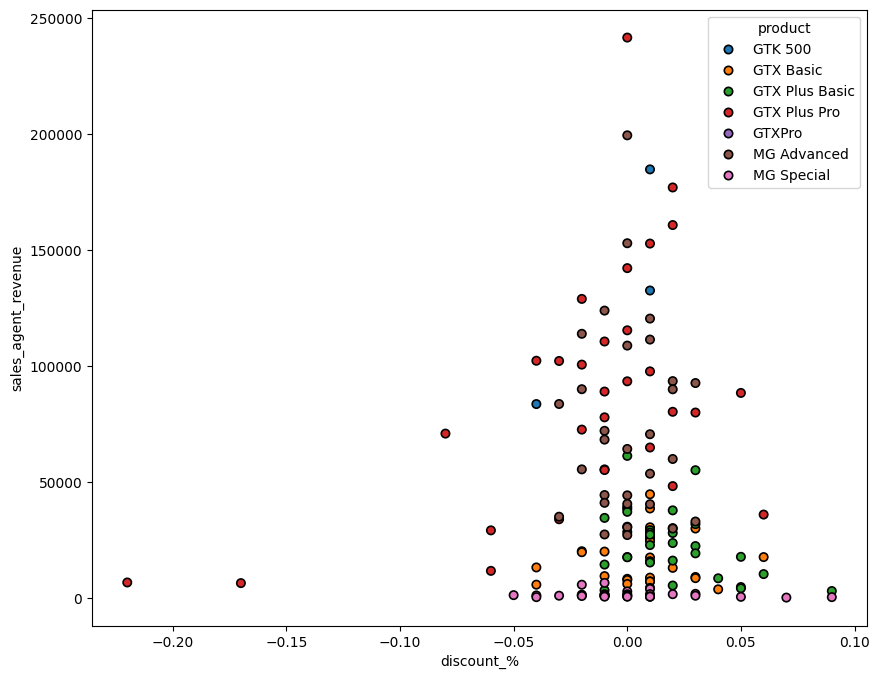

In [74]:
#plt.figure(figsize=(10,8))
#sns.scatterplot(x=resultf2['agent_per_unit_SP'], y=resultf2['opportunity_id'], hue=resultf2['product'], palette="tab10", edgecolor="black", linewidth=1.2)
#plt.show()

plt.figure(figsize=(10,8))
sns.scatterplot(x=resultf2['discount_%'], y=resultf2['sales_agent_revenue'], hue=resultf2['product'], palette="tab10", edgecolor="black", linewidth=1.2)
plt.show()



#### Selling Streaks and Patterns

In [75]:
sales_pipe_won_lost = sales_pipe[sales_pipe['deal_stage'].isin(['Won', 'Lost'])]
print(sales_pipe_won_lost.shape)
sales_pipe_won_lost

(6711, 10)


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,total_days_engaged
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-01,4514.0,Won,127.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-01,50.0,Won,127.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-01,588.0,Won,127.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-01,517.0,Won,127.0
...,...,...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-01,622.0,Won,-23.0
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-01,1093.0,Won,-23.0
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-01,4433.0,Won,-25.0
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-01,1052.0,Won,-26.0


In [76]:
#Analyzing streak and pattern of selling each product
resultg1 = sales_pipe_won_lost.groupby(['product', 'sales_agent', 'deal_stage','close_date'])['opportunity_id'].value_counts().reset_index()
#resultg1['deal_closed_date'] = sales_pipe_won_lost['close_date']
#resultg1 = resultg1.sort_values(by=['sales_agent'], ascending=[True])
#print(resultg1.shape)
resultg2 = resultg1.pivot_table(index=['product', 'sales_agent'], columns='deal_stage', values='opportunity_id', aggfunc='count', fill_value=0).reset_index()
resultg2['total_opportunities'] = resultg2['Won'] + resultg2['Lost']

resultg2 = resultg2.loc[:, ['sales_agent', 'product', 'total_opportunities', 'Won', 'Lost']].sort_values(by=['Won'], ascending=False)
resultg2['win_rate'] = (resultg2['Won']/resultg2['total_opportunities']).round(2)
resultg2.sort_values(by=['Won', 'win_rate'], ascending=[False, False])

deal_stage,sales_agent,product,total_opportunities,Won,Lost,win_rate
98,Darcel Schlecht,GTXPro,265,160,105,0.60
173,Versie Hillebrand,MG Special,169,117,52,0.69
148,Anna Snelling,MG Special,144,102,42,0.71
19,Kary Hendrixson,GTX Basic,129,82,47,0.64
18,Kami Bicknell,GTX Basic,108,71,37,0.66
...,...,...,...,...,...,...
110,Niesha Huffines,GTXPro,14,2,12,0.14
87,Rosalina Dieter,GTX Plus Pro,2,1,1,0.50
72,Elease Gluck,GTX Plus Pro,6,1,5,0.17
1,Darcel Schlecht,GTK 500,1,0,1,0.00


In [77]:
resultg3 = resultg1.groupby(['sales_agent', 'product', 'deal_stage', 'close_date'])['opportunity_id'].value_counts().reset_index()
resultg3 = resultg3.sort_values(by=['sales_agent', 'close_date'], ascending=[True, False])
resultg3=resultg3.drop(['count'], axis=1)
resultg4 = resultg3.sort_values(by=['sales_agent','close_date'], ascending=[True, False])
print(resultg4.shape)
resultg4

(6711, 5)


,sales_agent,product,deal_stage,close_date,opportunity_id
17,Anna Snelling,GTX Basic,Lost,2017-12-01,H29XGJ5H
18,Anna Snelling,GTX Basic,Lost,2017-12-01,JRSU8ALH
48,Anna Snelling,GTX Basic,Won,2017-12-01,04AOWMXV
49,Anna Snelling,GTX Basic,Won,2017-12-01,05HLE3JL
50,Anna Snelling,GTX Basic,Won,2017-12-01,AS3IYIRO
...,...,...,...,...,...
6627,Zane Levy,GTXPro,Won,2017-03-01,FZDRB789
6628,Zane Levy,GTXPro,Won,2017-03-01,L0345WKB
6629,Zane Levy,GTXPro,Won,2017-03-01,L5807I4N
6630,Zane Levy,GTXPro,Won,2017-03-01,S33WRL0Y


In [78]:
resultg4['close_month_year'] = resultg4['close_date'].dt.strftime("%m-%Y")
resultg4
resultg5 = resultg4.groupby(['sales_agent', 'product', 'close_month_year']).agg({'opportunity_id':'count'}).reset_index()
resultg5 = resultg5.sort_values(by=['sales_agent', 'close_month_year'], ascending=[True, False])
print(resultg5.shape)
resultg5

(1568, 4)


,sales_agent,product,close_month_year,opportunity_id
9,Anna Snelling,GTX Basic,12-2017,5
19,Anna Snelling,GTX Plus Basic,12-2017,4
29,Anna Snelling,GTX Plus Pro,12-2017,4
39,Anna Snelling,MG Advanced,12-2017,4
49,Anna Snelling,MG Special,12-2017,13
...,...,...,...,...
1510,Zane Levy,GTX Basic,03-2017,6
1520,Zane Levy,GTX Plus Basic,03-2017,6
1530,Zane Levy,GTX Plus Pro,03-2017,6
1539,Zane Levy,GTXPro,03-2017,5


In [79]:
#intiating rolling win probability (overall, not specific to products)
resultg6 = resultg4.sort_values(by= ['sales_agent', 'close_date'], ascending = [True, True])
resultg6=resultg6.drop(['product'], axis=1)
resultg6 = resultg6.pivot_table(index=['sales_agent', 'close_date'], columns='deal_stage', values='opportunity_id', aggfunc='count', fill_value=0).reset_index()
resultg6 = resultg6.sort_values(by= ['sales_agent', 'close_date'], ascending = [True, True])
resultg6['deals_in_a_day'] = resultg6['Won'] + resultg6['Lost']
resultg6
#dropping product column
resultg6['total_deals_so_far']=resultg6.groupby(['sales_agent'])['deals_in_a_day'].cumsum()
resultg6['wins_so_far']=resultg6.groupby(['sales_agent'])['Won'].cumsum()
resultg6['%rate_of_win'] = (resultg6['wins_so_far']/resultg6['total_deals_so_far']).round(2)
resultg6

deal_stage,sales_agent,close_date,Lost,Won,deals_in_a_day,total_deals_so_far,wins_so_far,%rate_of_win
0,Anna Snelling,2017-03-01,10,25,35,35,25,0.71
1,Anna Snelling,2017-04-01,13,17,30,65,42,0.65
2,Anna Snelling,2017-05-01,18,20,38,103,62,0.60
3,Anna Snelling,2017-06-01,2,34,36,139,96,0.69
4,Anna Snelling,2017-07-01,13,13,26,165,109,0.66
...,...,...,...,...,...,...,...,...
295,Zane Levy,2017-08-01,5,14,19,156,90,0.58
296,Zane Levy,2017-09-01,5,19,24,180,109,0.61
297,Zane Levy,2017-10-01,10,17,27,207,126,0.61
298,Zane Levy,2017-11-01,17,17,34,241,143,0.59


In [80]:
#intiating rolling win probability (overall, not specific to products)
resultg6 = resultg4.sort_values(by= ['sales_agent', 'close_date'], ascending = [True, True])
resultg6=resultg6.drop(['product'], axis=1)
resultg6 = resultg6.pivot_table(index=['sales_agent', 'close_date'], columns='deal_stage', values='opportunity_id', aggfunc='count', fill_value=0).reset_index()
resultg6 = resultg6.sort_values(by= ['sales_agent', 'close_date'], ascending = [True, True])
resultg6['deals_in_a_day'] = resultg6['Won'] + resultg6['Lost']
resultg6
#dropping product column
resultg6['total_deals_so_far']=resultg6.groupby(['sales_agent'])['deals_in_a_day'].cumsum()
resultg6['wins_so_far']=resultg6.groupby(['sales_agent'])['Won'].cumsum()
resultg6['%rate_of_win'] = (resultg6['wins_so_far']/resultg6['total_deals_so_far']).round(2)
resultg6

deal_stage,sales_agent,close_date,Lost,Won,deals_in_a_day,total_deals_so_far,wins_so_far,%rate_of_win
0,Anna Snelling,2017-03-01,10,25,35,35,25,0.71
1,Anna Snelling,2017-04-01,13,17,30,65,42,0.65
2,Anna Snelling,2017-05-01,18,20,38,103,62,0.60
3,Anna Snelling,2017-06-01,2,34,36,139,96,0.69
4,Anna Snelling,2017-07-01,13,13,26,165,109,0.66
...,...,...,...,...,...,...,...,...
295,Zane Levy,2017-08-01,5,14,19,156,90,0.58
296,Zane Levy,2017-09-01,5,19,24,180,109,0.61
297,Zane Levy,2017-10-01,10,17,27,207,126,0.61
298,Zane Levy,2017-11-01,17,17,34,241,143,0.59


In [81]:
#product demand over time

#engage date range
print(sales_pipe['engage_date'].min())
print(sales_pipe['engage_date'].max())
print((sales_pipe['engage_date'].max())-(sales_pipe['engage_date'].min()))

2016-10-20 00:00:00
2017-12-27 00:00:00
433 days 00:00:00


In [82]:
resulth1 = sales_pipe.groupby(['product', 'engage_date', 'close_date', 'deal_stage'])['opportunity_id'].count().reset_index()
resulth1.columns = ['product', 'engage_date', 'close_date', 'deal_stage', 'total_opportunities']
resulth1=resulth1.sort_values(['product', 'engage_date'], ascending=[True, True])
#resulth1['engage_date'] = pd.to_datetime(resulth1['engage_date']).dt.date
#resulth1['close_date'] = pd.to_datetime(resulth1['close_date']).dt.date
resulth1

,product,engage_date,close_date,deal_stage,total_opportunities
0,GTK 500,2016-11-20,2017-03-01,Won,1
1,GTK 500,2017-02-01,2017-06-01,Won,1
2,GTK 500,2017-02-02,2017-05-01,Lost,1
3,GTK 500,2017-02-27,2017-06-01,Won,1
4,GTK 500,2017-03-15,2017-05-01,Lost,1
...,...,...,...,...,...
4696,MG Special,2017-12-18,2017-12-01,Won,1
4697,MG Special,2017-12-19,2017-12-01,Won,1
4698,MG Special,2017-12-21,2017-12-01,Won,2
4699,MG Special,2017-12-22,2017-12-01,Lost,1


In [83]:
#creating a product demand visualization based on engage date, deal stage, and total opportunities
#resulth1['close_month'] = resulth1['close_date'].dt.strftime("%m-%Y")
resulth1['engage_month'] = resulth1['engage_date'].dt.strftime("%m-%Y")
'''
sns.catplot(
    data=resulth1,
    kind="bar",
    x="engage_month", y="total_opportunities",
    hue="deal_stage", col="product",
    ci=None, palette="Set2", height=4, aspect=1.2
)
'''

'\nsns.catplot(\n    data=resulth1,\n    kind="bar",\n    x="engage_month", y="total_opportunities",\n    hue="deal_stage", col="product",\n    ci=None, palette="Set2", height=4, aspect=1.2\n)\n'

In [84]:
resulth1['engage_month'] = pd.to_datetime(resulth1['engage_month'], format='%m-%Y')

pivot_resulth1 = resulth1.pivot_table(
    index=["engage_month", "product"],
    columns="deal_stage",
    values="total_opportunities",
    aggfunc="sum",
    fill_value=0
).reset_index()

print(pivot_resulth1.dtypes)
pivot_resulth1

deal_stage
engage_month    datetime64[ns]
product                 object
Lost                     int64
Won                      int64
dtype: object


deal_stage,engage_month,product,Lost,Won
0,2016-10-01,GTX Basic,0,2
1,2016-10-01,GTX Plus Basic,0,1
2,2016-10-01,GTXPro,0,1
3,2016-10-01,MG Special,0,3
4,2016-11-01,GTK 500,0,1
...,...,...,...,...
93,2017-12-01,GTX Plus Basic,6,18
94,2017-12-01,GTX Plus Pro,0,8
95,2017-12-01,GTXPro,5,10
96,2017-12-01,MG Advanced,2,10


['GTX Basic' 'GTX Plus Basic' 'GTXPro' 'MG Special' 'GTK 500'
 'GTX Plus Pro' 'MG Advanced']


-----  ****** 


Data Subset: deal_stage engage_month  Lost  Won
0            2016-10-01     0    2
1            2016-11-01     2   18
2            2016-12-01     9   41
3            2017-01-01    12   35
4            2017-02-01    35   66
5            2017-03-01    50  102
6            2017-04-01    85   98
7            2017-05-01    41   82
8            2017-06-01    52   84
9            2017-07-01    68   90
10           2017-08-01    32   81
11           2017-09-01    48   83
12           2017-10-01    65   85
13           2017-11-01    17   39
14           2017-12-01     5    9



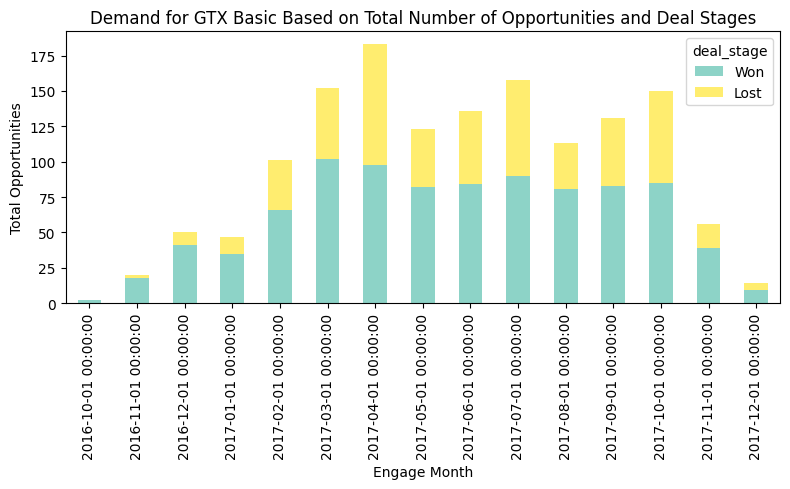



-----  ****** 


Data Subset: deal_stage engage_month  Lost  Won
0            2016-10-01     0    1
1            2016-11-01     3   14
2            2016-12-01     7   24
3            2017-01-01    10   26
4            2017-02-01    29   39
5            2017-03-01    27   56
6            2017-04-01    47   69
7            2017-05-01    29   70
8            2017-06-01    31   66
9            2017-07-01    54   75
10           2017-08-01    36   58
11           2017-09-01    50   57
12           2017-10-01    54   55
13           2017-11-01    15   25
14           2017-12-01     6   18



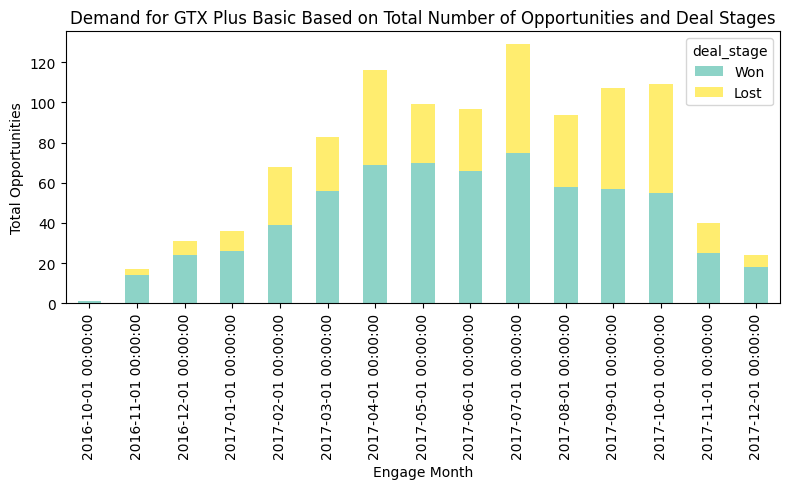



-----  ****** 


Data Subset: deal_stage engage_month  Lost  Won
0            2016-10-01     0    1
1            2016-11-01     3   11
2            2016-12-01     6   22
3            2017-01-01    14   28
4            2017-02-01    21   46
5            2017-03-01    38   69
6            2017-04-01    54   89
7            2017-05-01    42   64
8            2017-06-01    44   74
9            2017-07-01    62   72
10           2017-08-01    31   54
11           2017-09-01    38   88
12           2017-10-01    47   78
13           2017-11-01    13   23
14           2017-12-01     5   10



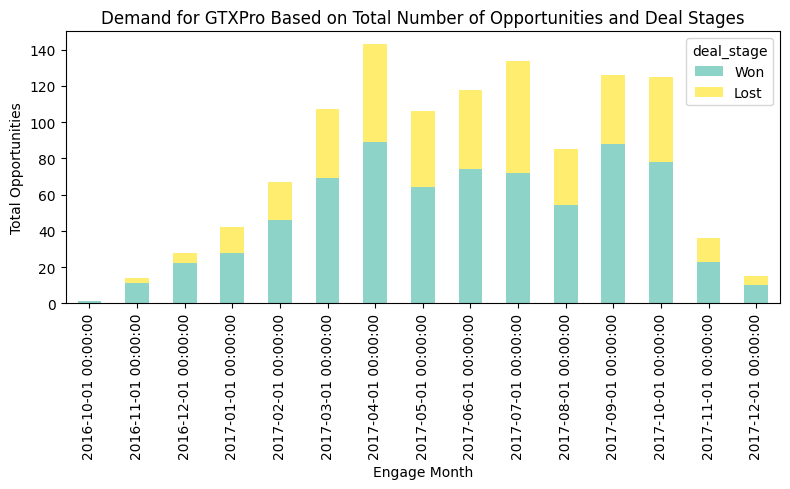



-----  ****** 


Data Subset: deal_stage engage_month  Lost  Won
0            2016-10-01     0    3
1            2016-11-01     5   17
2            2016-12-01     6   36
3            2017-01-01    15   40
4            2017-02-01    28   29
5            2017-03-01    43   87
6            2017-04-01    47   77
7            2017-05-01    40   64
8            2017-06-01    38   97
9            2017-07-01    51   69
10           2017-08-01    38   70
11           2017-09-01    48   89
12           2017-10-01    55   65
13           2017-11-01    11   25
14           2017-12-01     5   25



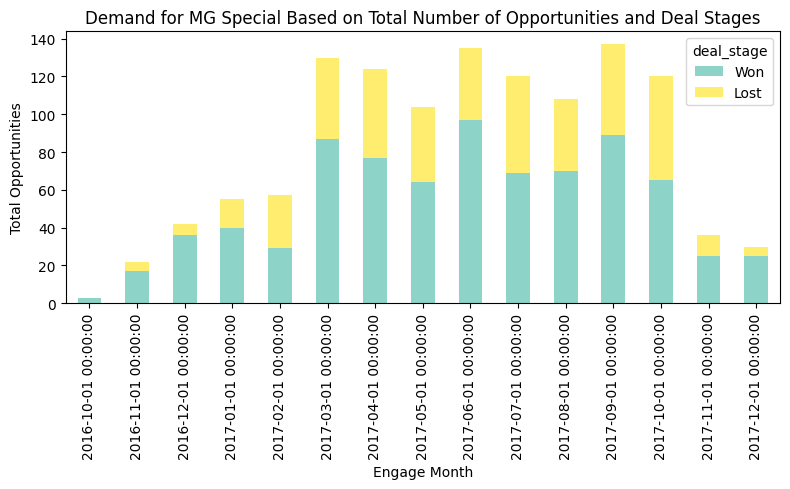



-----  ****** 


Data Subset: deal_stage engage_month  Lost  Won
0            2016-11-01     0    1
1            2017-02-01     1    2
2            2017-03-01     3    1
3            2017-04-01     0    3
4            2017-05-01     0    3
5            2017-06-01     1    2
6            2017-07-01     1    0
7            2017-09-01     0    1
8            2017-10-01     3    1
9            2017-11-01     1    1



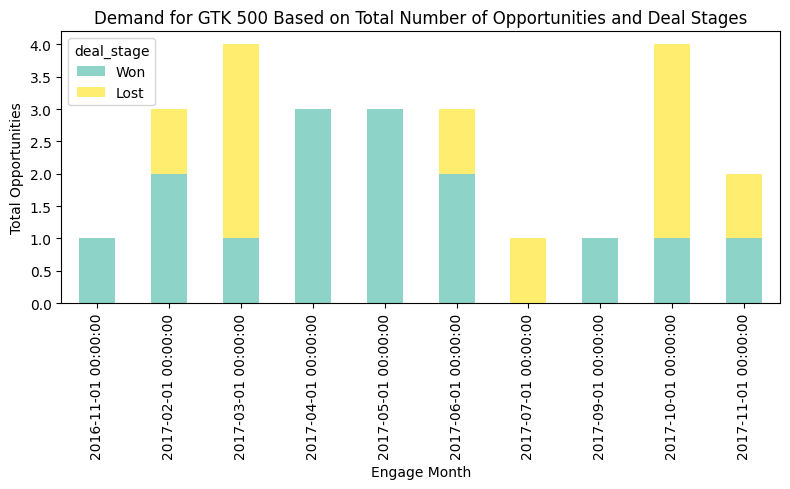



-----  ****** 


Data Subset: deal_stage engage_month  Lost  Won
0            2016-11-01     2    8
1            2016-12-01     4   18
2            2017-01-01     2   23
3            2017-02-01    13   39
4            2017-03-01    22   47
5            2017-04-01    34   42
6            2017-05-01    25   30
7            2017-06-01    21   52
8            2017-07-01    49   56
9            2017-08-01    18   34
10           2017-09-01    34   48
11           2017-10-01    28   51
12           2017-11-01    14   23
13           2017-12-01     0    8



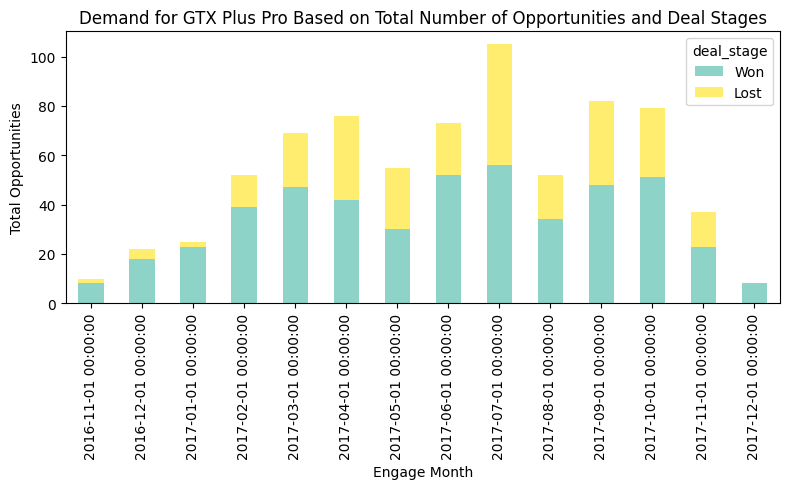



-----  ****** 


Data Subset: deal_stage engage_month  Lost  Won
0            2016-11-01     4   14
1            2016-12-01     4   19
2            2017-01-01    13   29
3            2017-02-01    16   56
4            2017-03-01    32   78
5            2017-04-01    59   49
6            2017-05-01    45   53
7            2017-06-01    41   78
8            2017-07-01    70   79
9            2017-08-01    43   44
10           2017-09-01    34   59
11           2017-10-01    51   65
12           2017-11-01    16   21
13           2017-12-01     2   10



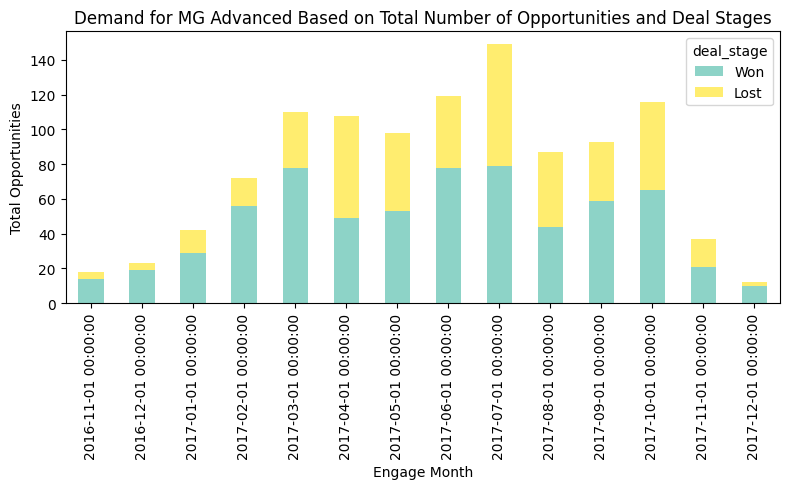

In [85]:
products = pivot_resulth1["product"].unique()
print(products)

for product in products:
    figure_resulth1 = pivot_resulth1[pivot_resulth1["product"] == product].set_index("engage_month").reset_index()
    #print(sub_df)
    #sub_df[sub_df.columns.drop("product")]

    figure_resulth2 = figure_resulth1[figure_resulth1.columns.drop("product")]
    print(f"\n\n-----  ****** \n\n\nData Subset: {figure_resulth2}\n")
   # figure_resulth2 = figure_resulth2.sort_values(by= 'engage_month', ascending=True)

    figure_resulth2.plot(
        x= "engage_month",
        y=['Won', 'Lost'],
        kind="bar",
        stacked=True,
        colormap = "Set3",
        figsize=(8,5)
    )
    plt.title(f"Demand for {product} Based on Total Number of Opportunities and Deal Stages")
    plt.xlabel("Engage Month")
    plt.ylabel("Total Opportunities")
    plt.tight_layout()
    plt.show()

#Statistical Tests

In [86]:
# View all datasets and data substes created so far
# We will not be using any of the data subsets developed or modified in the EDA
# To maintain the original data information, we will be using the datasets/subsets from Data Pre-Processing